# ViT-SOM training on MNIST dataset

Training of both ViT-SOM models with 24x24 and 40x40 grids to compare achieved performance with the authors implementation

In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import ConcatDataset

import numpy as np
import matplotlib.pyplot as plt


from ViTSOM import AutoEncoder, ViTLoss, SomLoss
from help_functions import get_grid_coords, decay_exponential, calculate_QE_TE_Purity, plot_som_pie_grid, plot_umap_som_weights, get_node_hits, plot_som_mnist, plot_som_weights, visualize_u_matrix_extended, generate_extended_u_matrix

Download and concatenate the dataset

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])

train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
dataset = ConcatDataset([train_set, test_set])

## ViT-SOM with 24x24 grid

In [3]:
config_paper = {
    'img_size': 28,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'som_rows': 24,
    'som_cols': 24,
    'epochs': 100,
    'lr': 0.0005,
}

Initialize the ViT-SOM

Details:
- Image size of 28
- Pixel size of 4
- 1 image channel
- Embedding dimension of 16
- Encoder depth of 4
- Decoder depth of 2
- 2 self-attention head
- MLP hidden dimension of size 64
- 24 SOM rows
- 24 SOM columns
- 100 training epochs
- Learning rate of 0.0005


In [4]:
autoencoder = AutoEncoder(img_size=config_paper['img_size'], 
                          patch_size=config_paper['patch_size'], 
                          num_of_channels=config_paper['num_of_channels'], 
                          embed_dim=config_paper['embed_dim'], 
                          enc_depth=config_paper['enc_depth'],                                      
                          dec_depth=config_paper['dec_depth'], 
                          num_heads=config_paper['num_heads'], 
                          mlp_dim=config_paper['mlp_dim'], 
                          som_rows=config_paper['som_rows'], 
                          som_cols=config_paper['som_cols'])    

In [5]:
# Initialize optimizer, dataloader, loss functions and scheduler
optimizer = optim.AdamW(autoencoder.parameters(), lr=config_paper['lr'])
loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
criterionViT = ViTLoss()
criterionSOM = SomLoss()
scheduler = CosineAnnealingLR(optimizer, T_max=config_paper['epochs'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder.to(device)
autoencoder.train()

# starting and ending value of sigma, beta is calculated to reach sigma_end at last epoch
sigma_start = config_paper['som_rows'] / 2.0
sigma_end = 0.001
beta = (sigma_end / sigma_start) ** (1 / config_paper['epochs'])

# get grid coordinates of each cell on the SOM grid
grid_coords = get_grid_coords(config_paper['som_rows'], config_paper['som_cols'], device)
current_sigma = sigma_start

history = {'total': [], 'mse': [], 'som': [], 'purity': [], 'QE': [], 'TE': []}

# checkpoints and snapshots for visualizations
checkpoints = [0,10,20,30,40,50,60,70,80,90,100]
snapshot_som_weights = {}

snapshot_som_weights[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

# set to calculate unique labels
unique_labels = set()

warmup_epochs = 20
target_gamma = 0.01
print("Start training")
for epoch in range(config_paper['epochs']):
    running_loss = 0.0
    running_mse = 0.0
    running_som = 0.0
    
    # calculate current sigma value
    sigma_t = decay_exponential(sigma_start, beta, epoch)
    
    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        # calculate the total loss using the linear warmup
        l_nn = criterionViT(images, reconstructed)
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        if epoch < warmup_epochs:
            gamma = target_gamma * (epoch / warmup_epochs)
        else:
            gamma = target_gamma
        total_loss = l_nn + gamma * l_som
        
        # update the weights of the network
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_mse += l_nn.item()
        running_som += l_som.item()
    
    if epoch+1 in checkpoints:      
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights[epoch+1] = (weights_np, labels_np)
        
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()
    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_total = running_loss / len(loader)
    avg_mse = running_mse / len(loader)
    avg_som = running_som / len(loader)
    
    history['total'].append(avg_total)
    history['mse'].append(avg_mse)
    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config_paper['epochs']} | Sigma: {sigma_t:.2f} | Loss: {avg_total:.8f} (MSE: {avg_mse:.8f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")


Start training
Epoch 1/100 | Sigma: 12.00 | Loss: 0.01053980 (MSE: 0.01053980 | SOM: 390.09180499) | QE: 0.8656 | TE: 0.9999 | Purity: 0.14076
Epoch 2/100 | Sigma: 10.92 | Loss: 0.06056389 (MSE: 0.00135777 | SOM: 118.41223238) | QE: 0.0729 | TE: 1.0000 | Purity: 0.11256
Epoch 3/100 | Sigma: 9.94 | Loss: 0.01102751 (MSE: 0.00102741 | SOM: 10.00010146) | QE: 0.0014 | TE: 1.0000 | Purity: 0.15906
Epoch 4/100 | Sigma: 9.05 | Loss: 0.00168447 (MSE: 0.00090571 | SOM: 0.51917214) | QE: 0.0004 | TE: 0.6695 | Purity: 0.46156
Epoch 5/100 | Sigma: 8.24 | Loss: 0.00098884 (MSE: 0.00081635 | SOM: 0.08624471) | QE: 0.0003 | TE: 0.2848 | Purity: 0.57770
Epoch 6/100 | Sigma: 7.50 | Loss: 0.00087332 (MSE: 0.00074374 | SOM: 0.05183190) | QE: 0.0003 | TE: 0.0354 | Purity: 0.58097
Epoch 7/100 | Sigma: 6.83 | Loss: 0.00070357 (MSE: 0.00058293 | SOM: 0.04021202) | QE: 0.0003 | TE: 0.0140 | Purity: 0.58774
Epoch 8/100 | Sigma: 6.22 | Loss: 0.00064529 (MSE: 0.00053473 | SOM: 0.03158910) | QE: 0.0002 | TE: 0.0

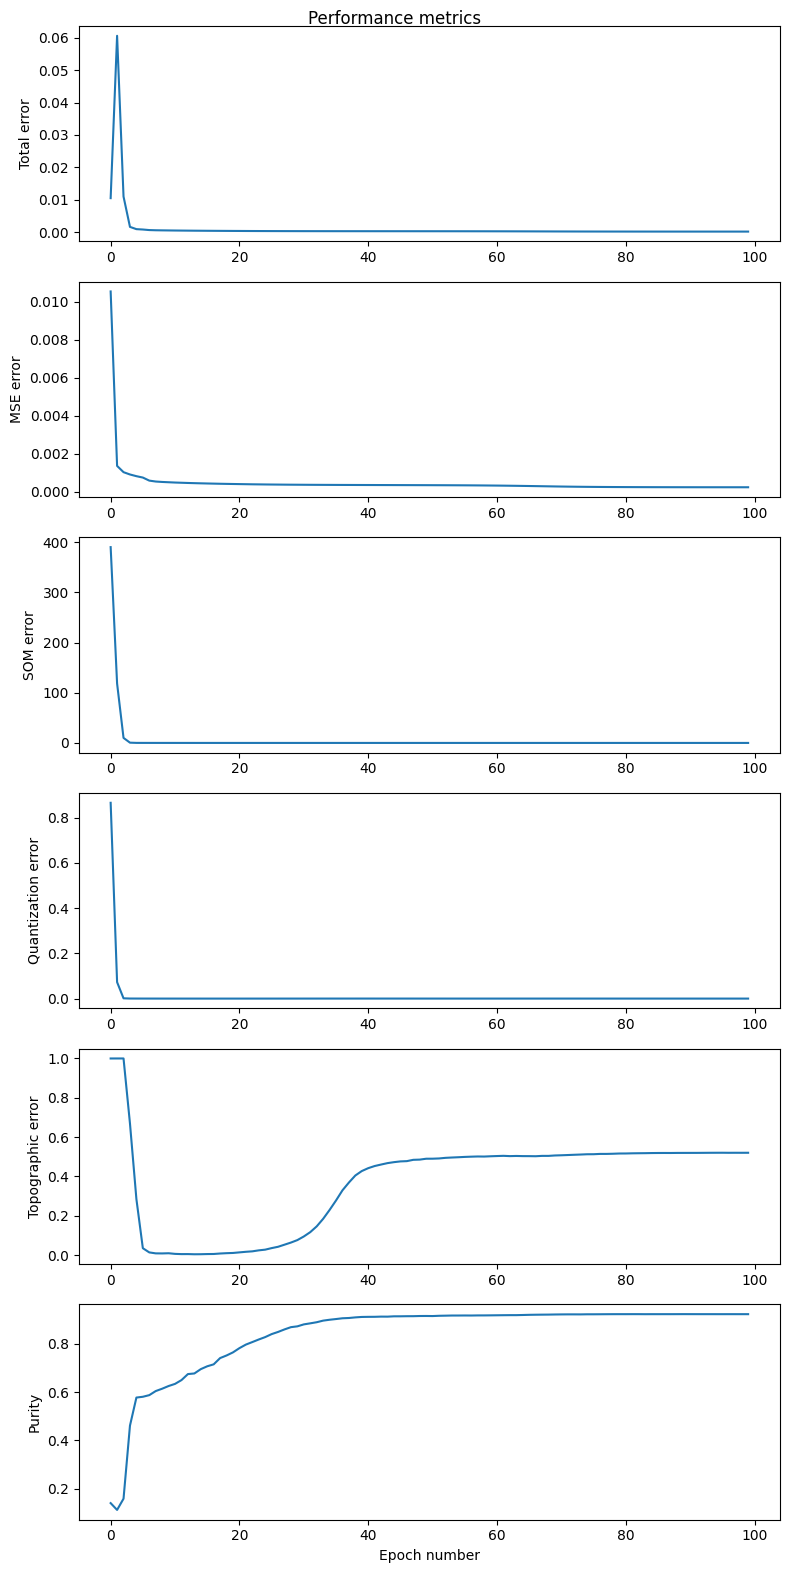

In [11]:
plt.figure(figsize=(8, 16))
plt.subplot(6,1,1)
plt.plot(np.arange(config_paper['epochs']), history['total'])
plt.ylabel('Total error')
plt.subplot(6,1,2)
plt.plot(np.arange(config_paper['epochs']), history['mse'])
plt.ylabel('MSE error')
plt.subplot(6,1,3)
plt.plot(np.arange(config_paper['epochs']), history['som'])
plt.ylabel('SOM error')
plt.subplot(6,1,4)
plt.plot(np.arange(config_paper['epochs']), history['QE'])
plt.ylabel('Quantization error')
plt.subplot(6,1,5)
plt.plot(np.arange(config_paper['epochs']), history['TE'])
plt.ylabel('Topographic error')
plt.subplot(6,1,6)
plt.plot(np.arange(config_paper['epochs']), history['purity'])
plt.ylabel('Purity')
plt.xlabel('Epoch number')
plt.suptitle("Performance metrics")
plt.tight_layout()
plt.savefig("performance_metrics.png", dpi=300, bbox_inches='tight')
plt.show()

Plot the change of the label matrix throughout the training process

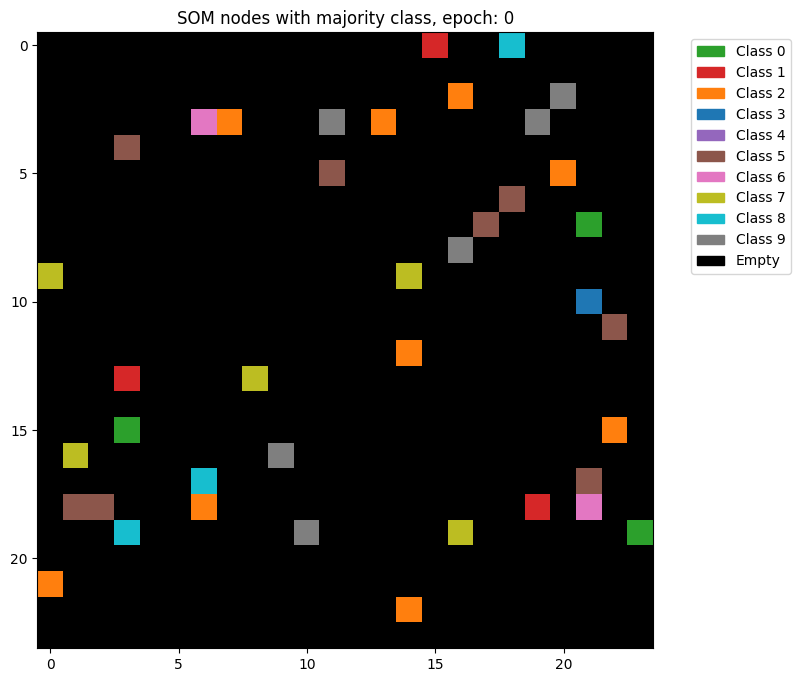

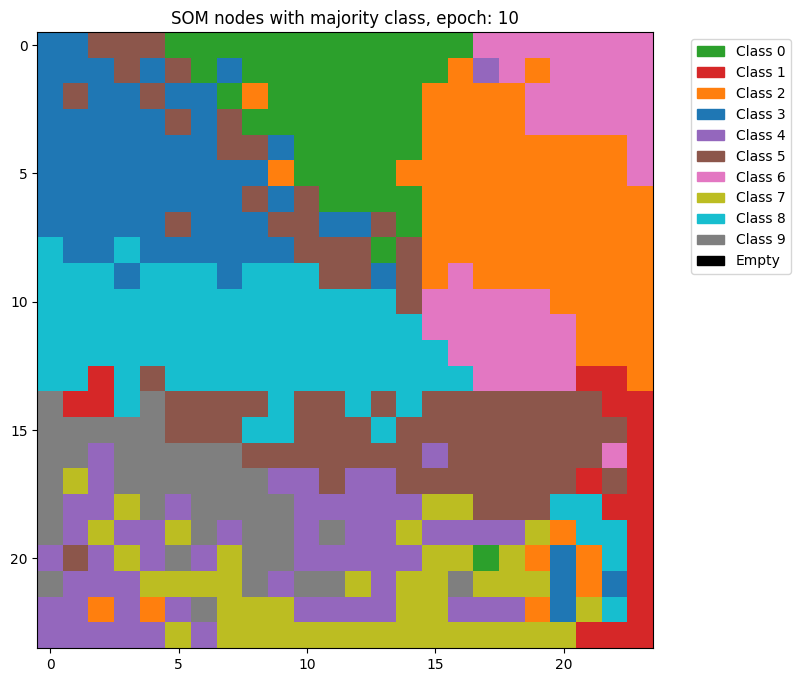

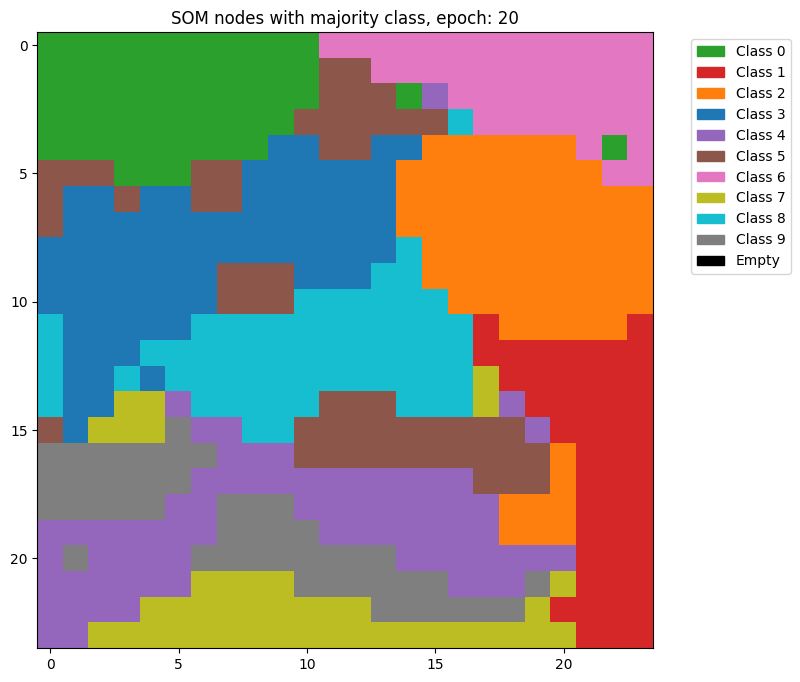

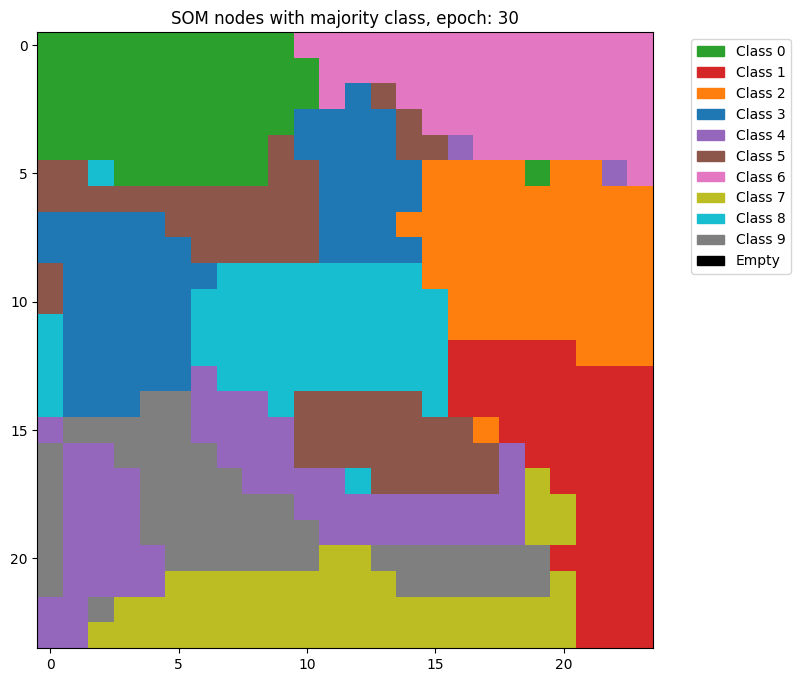

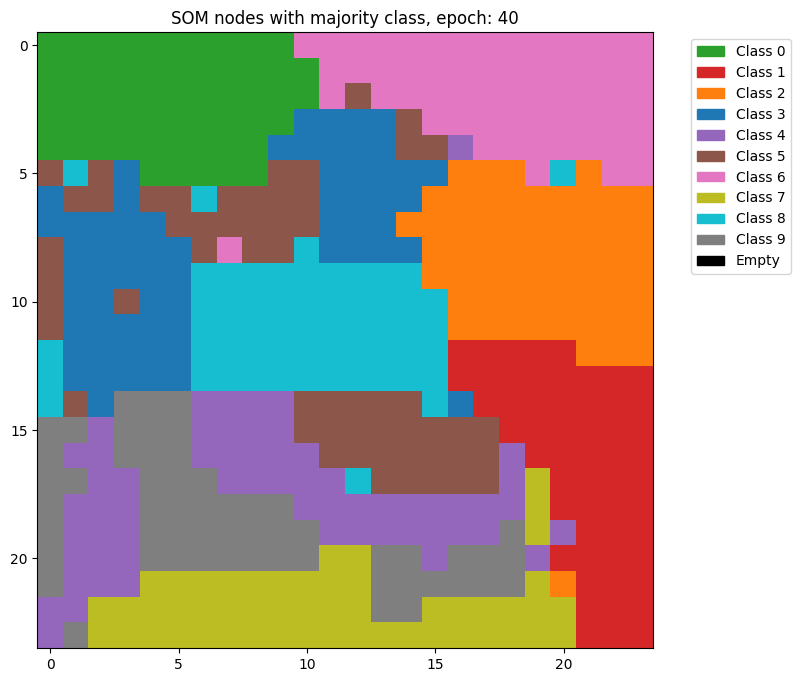

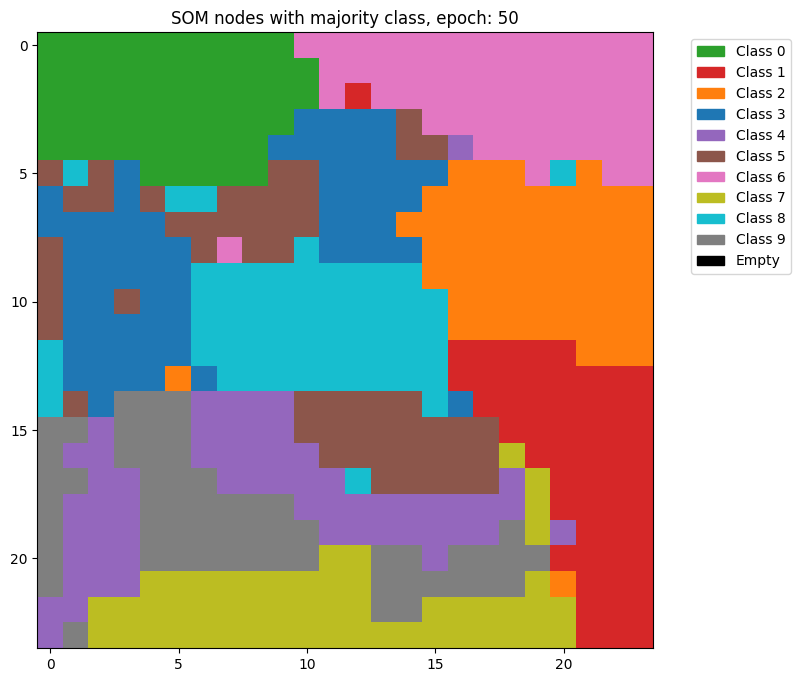

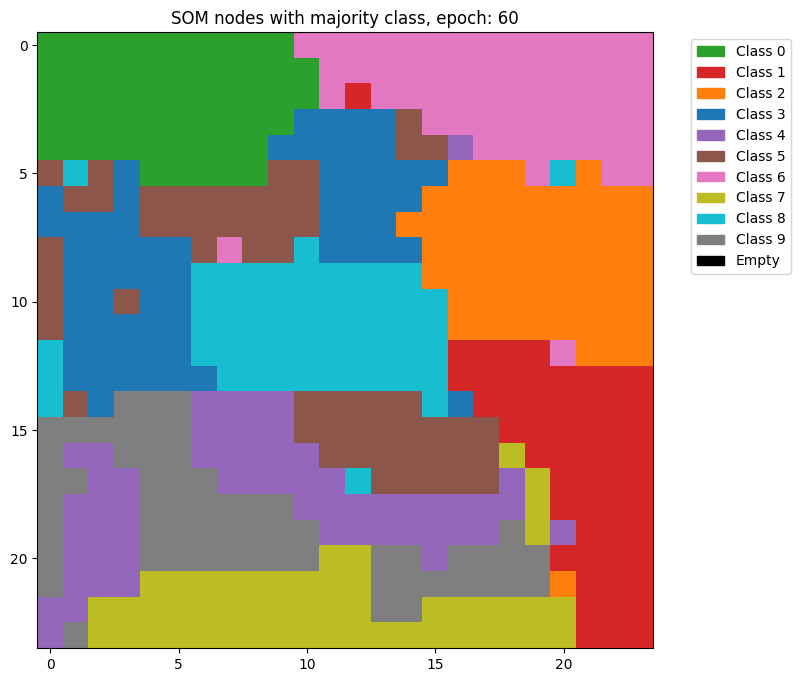

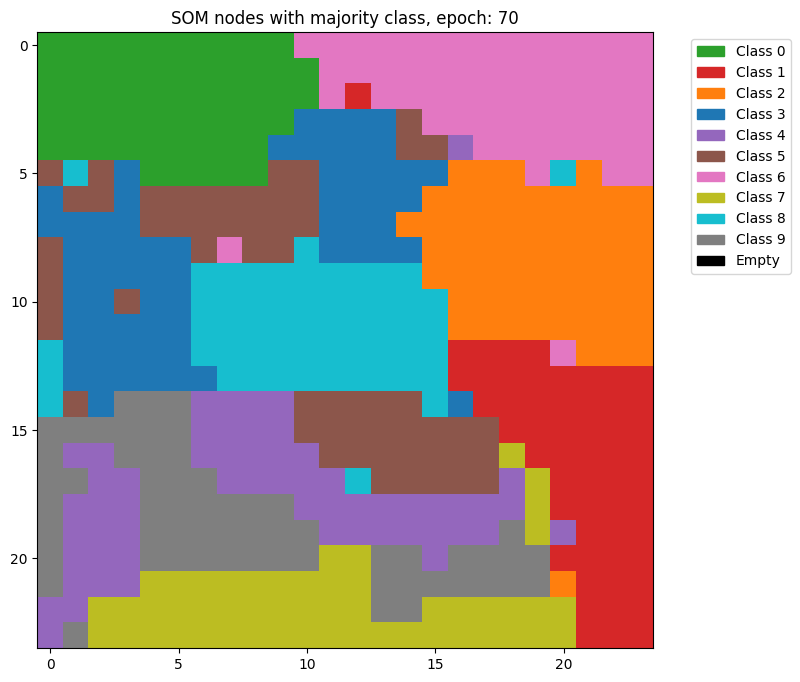

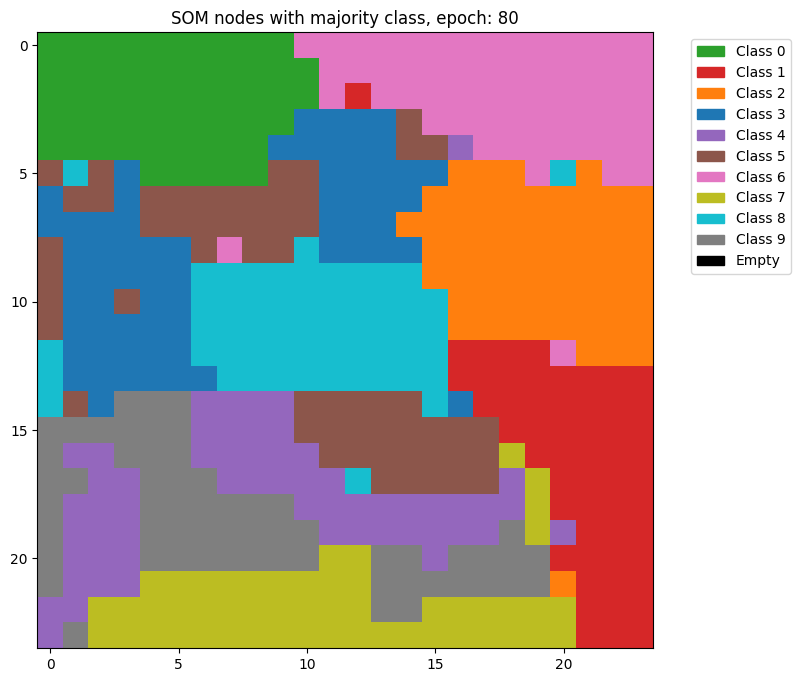

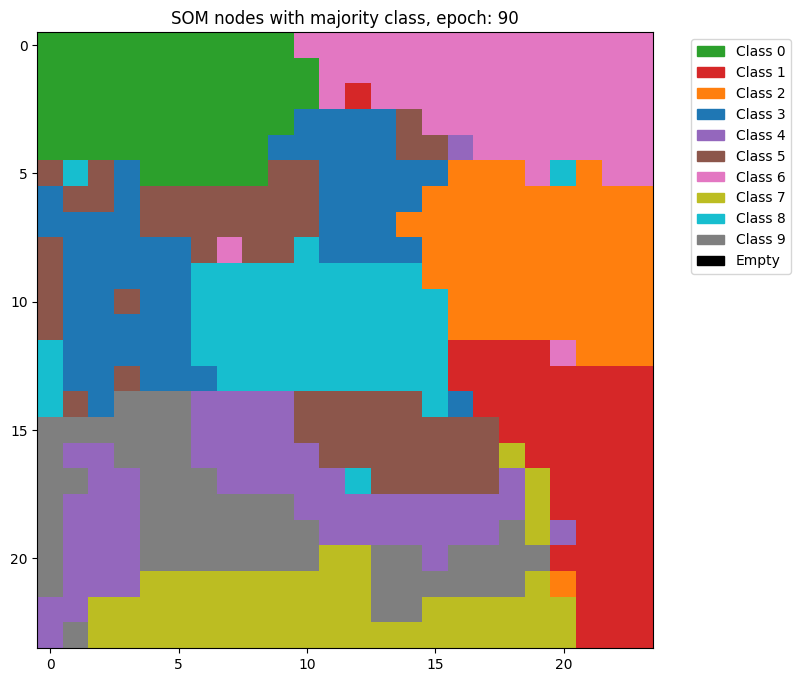

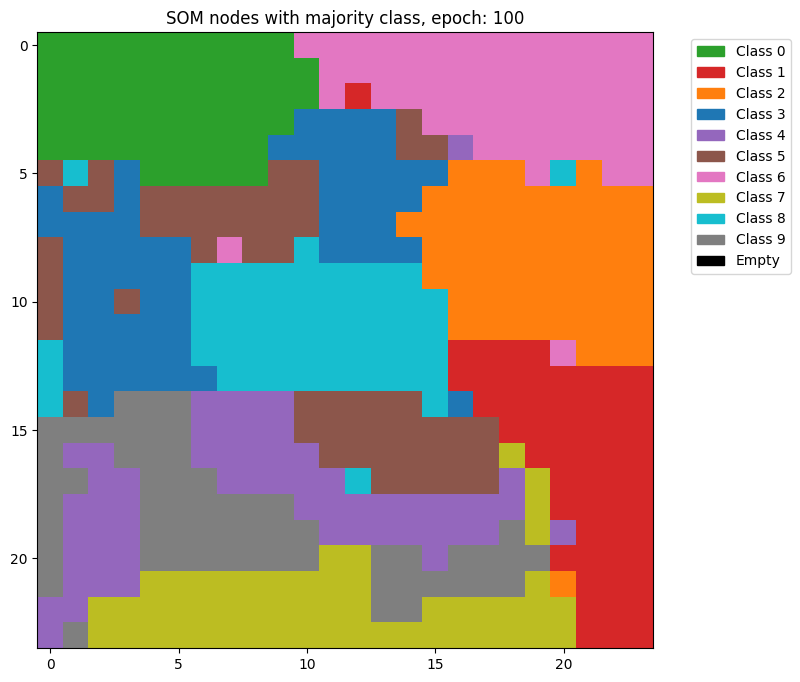

In [6]:
plot_som_weights(snapshot_som_weights, config_paper['som_rows'], config_paper['som_cols'], unique_labels)

Plot the extended U-Matrix

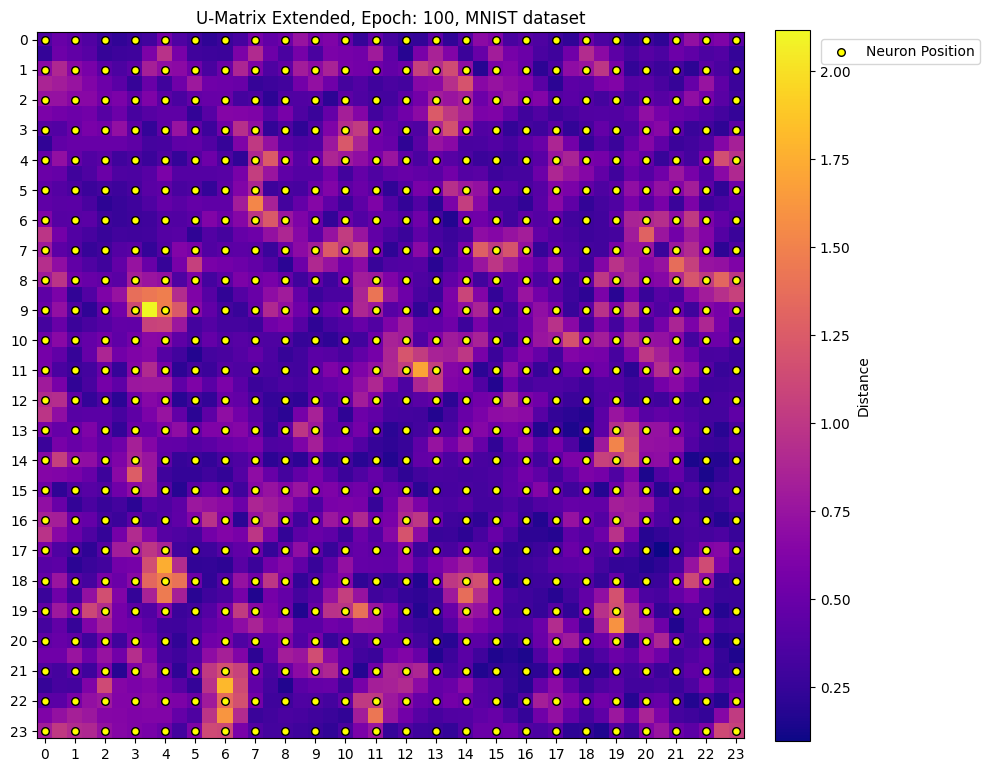

In [7]:
rows, cols = autoencoder.get_som_shape()
matrix = generate_extended_u_matrix(autoencoder.get_som_weights().detach().cpu().numpy(), rows, cols)
visualize_u_matrix_extended(matrix, 100, "MNIST")

Plot the change of the UMAP throughout the training process

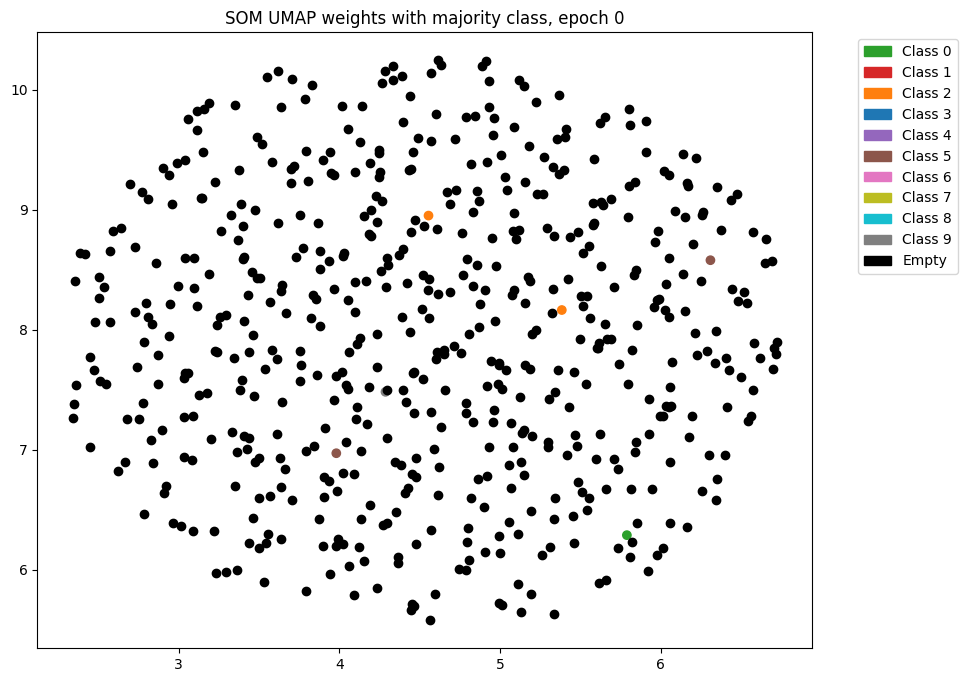

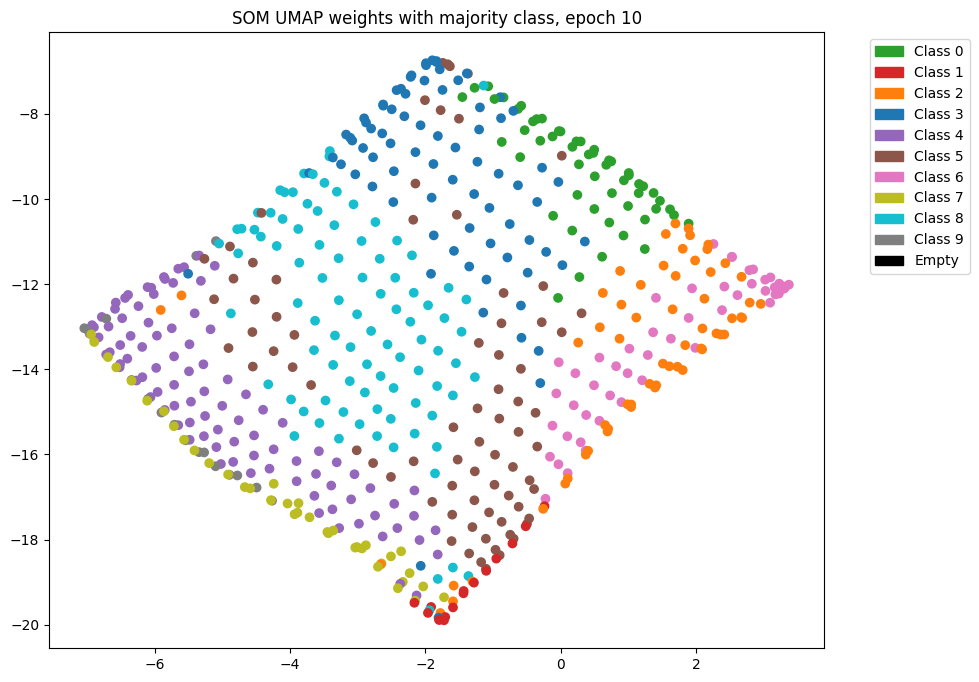

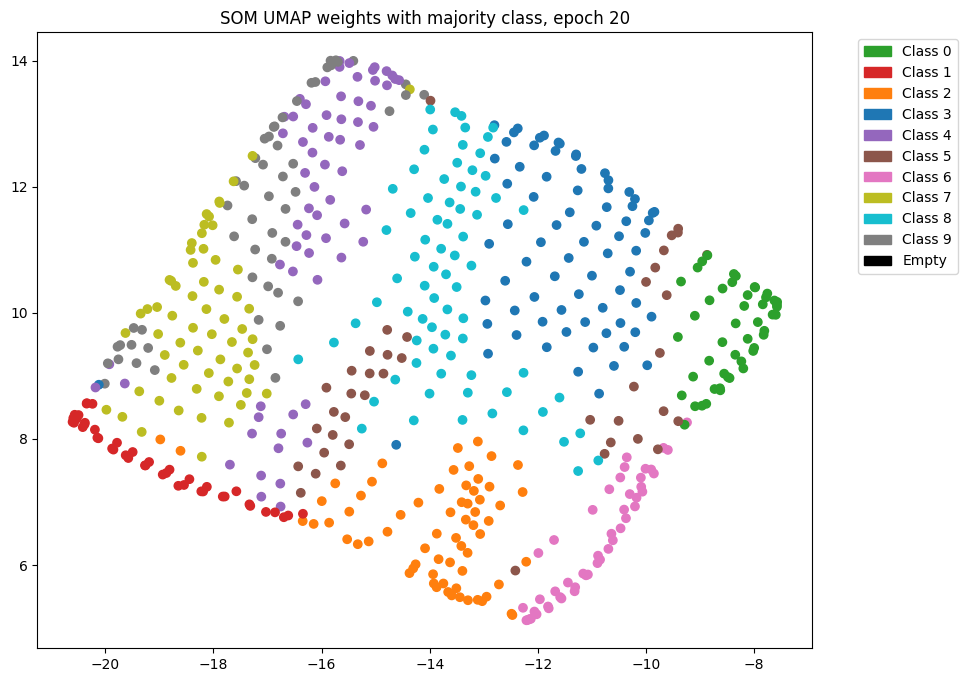

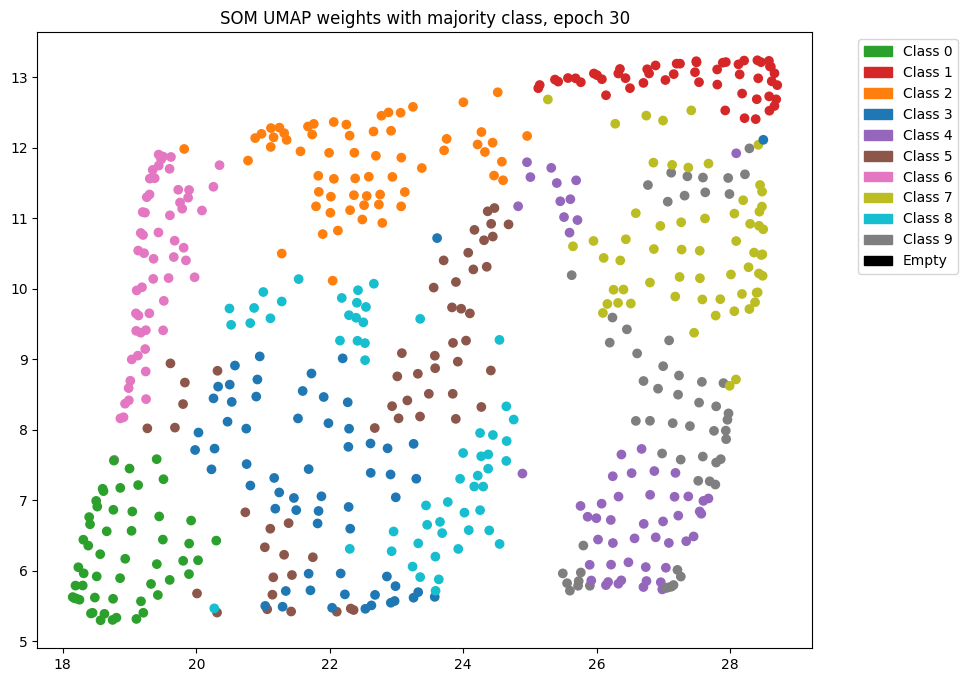

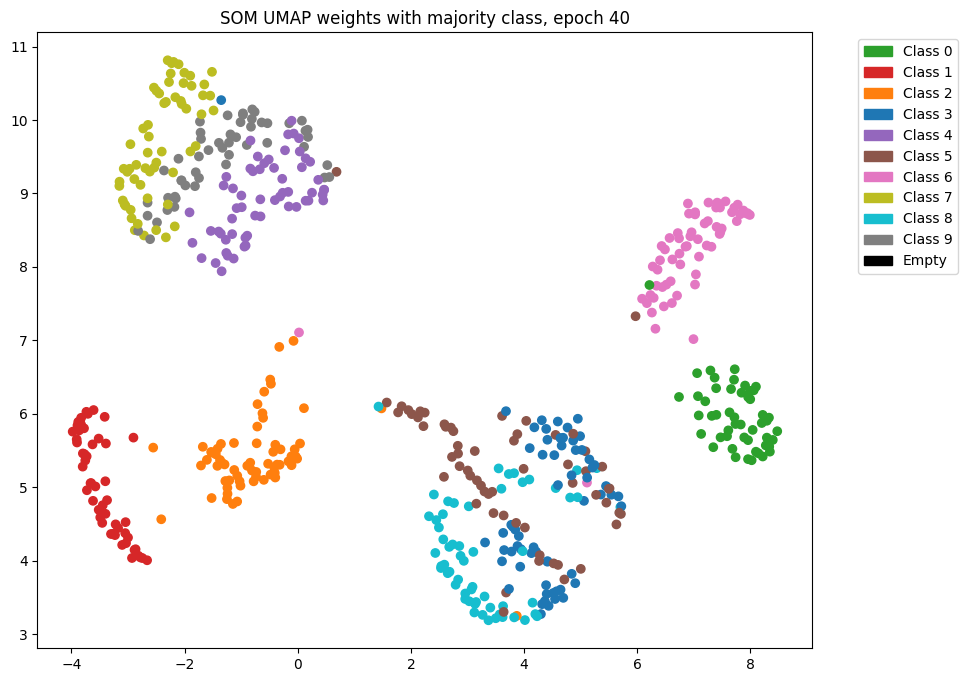

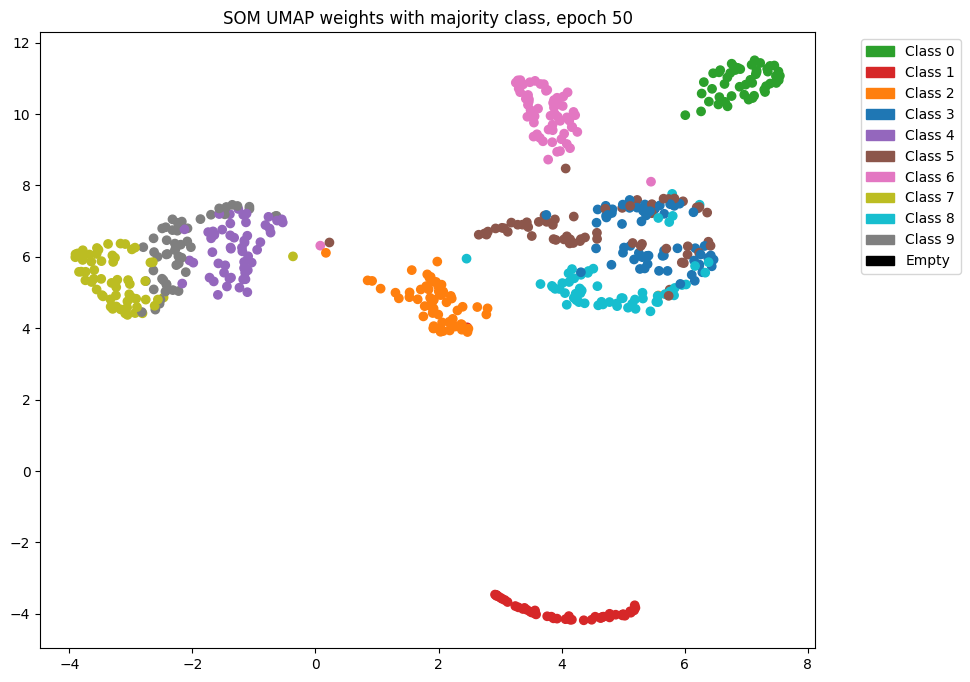

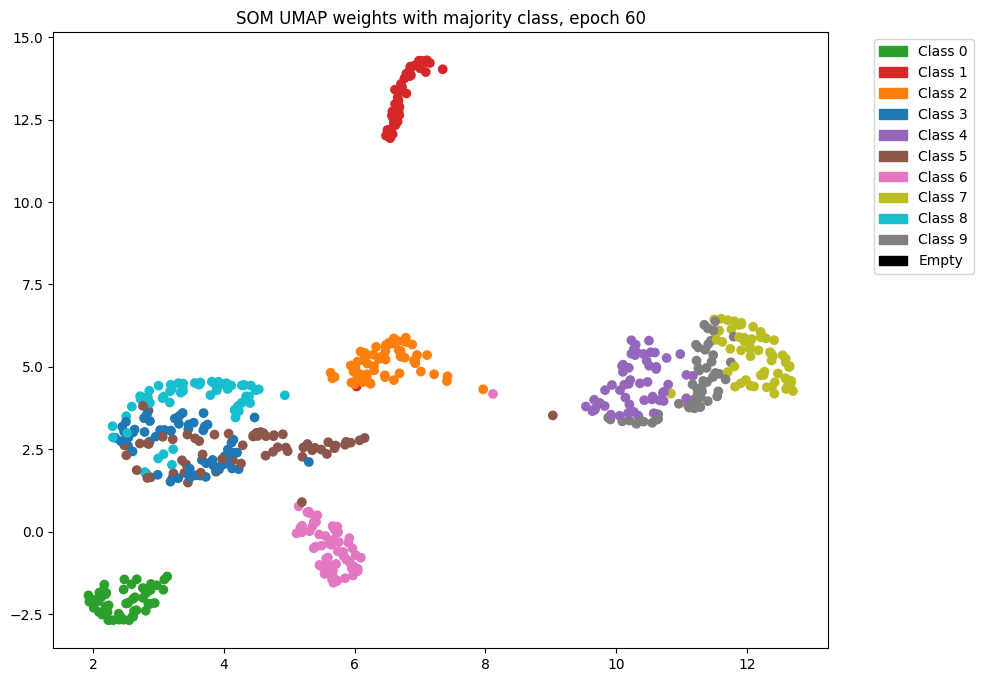

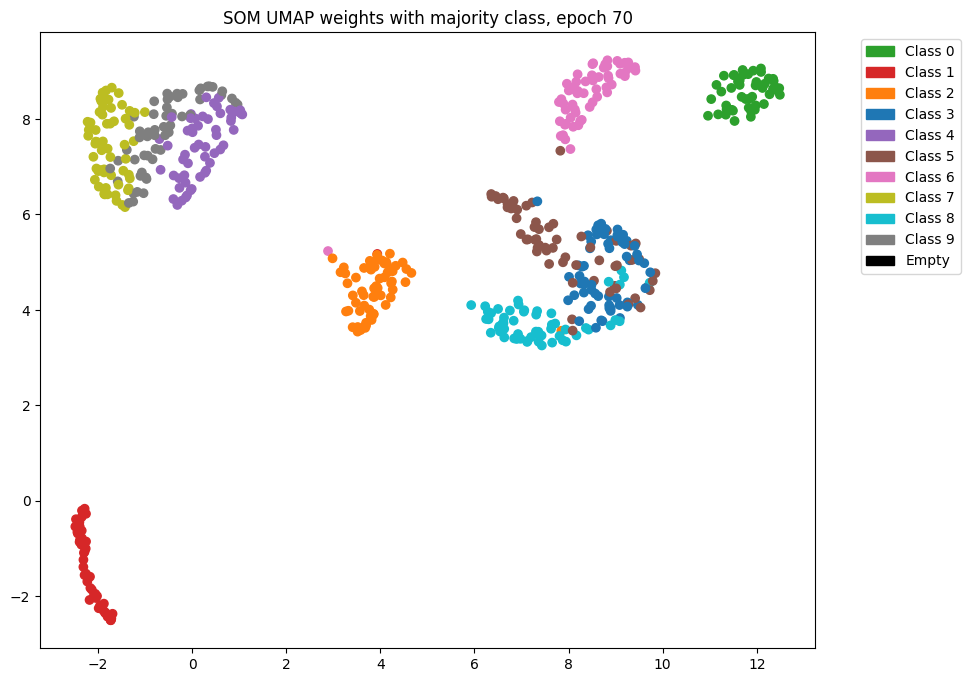

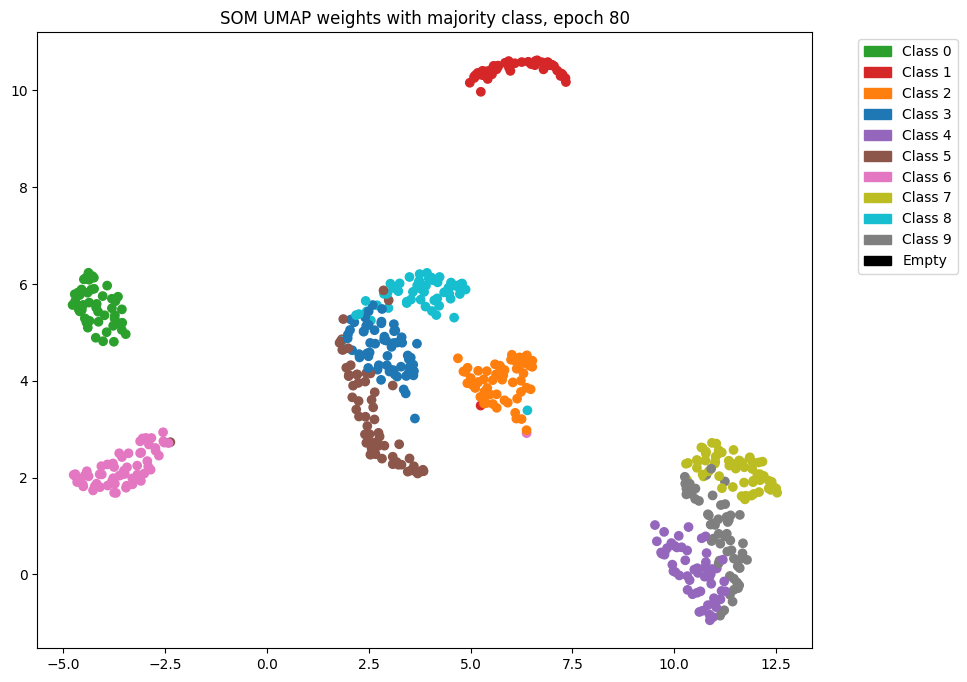

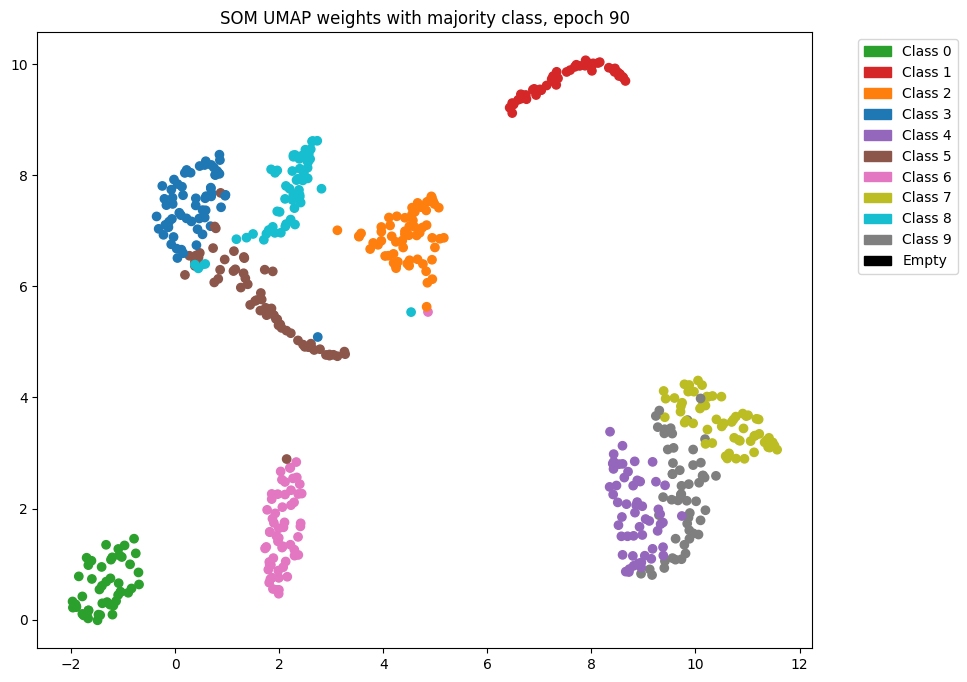

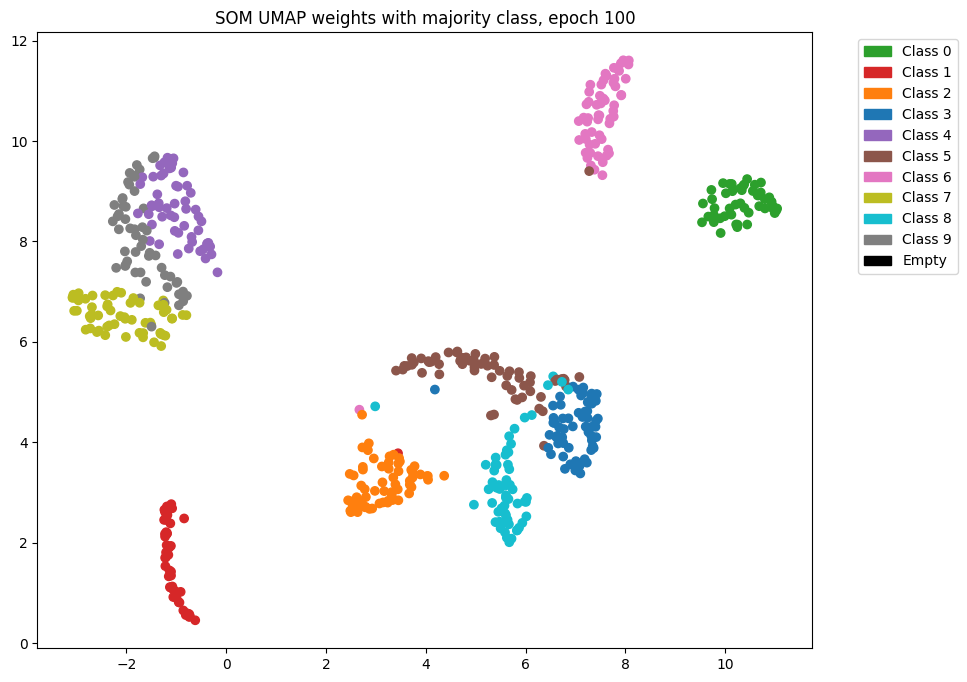

In [25]:
plot_umap_som_weights(snapshot_som_weights, unique_labels)

Plot the majority label with the numbers representing the class

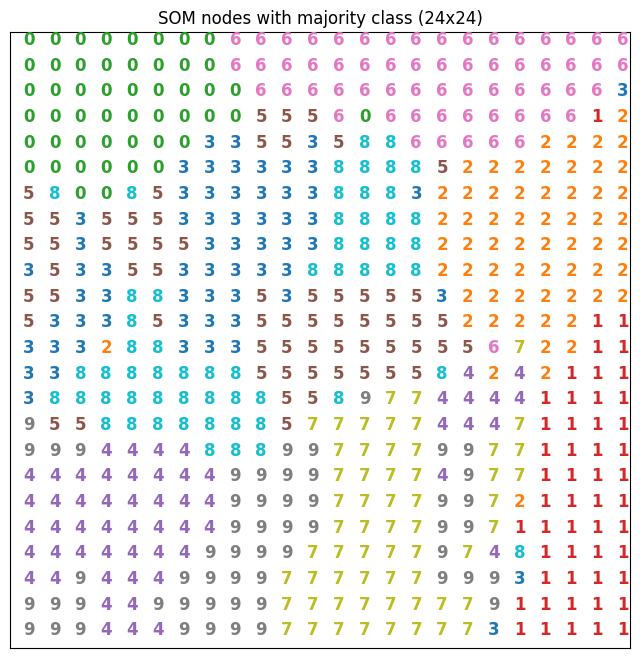

In [26]:
plot_som_mnist(snapshot_som_weights, config_paper['som_rows'], config_paper['som_cols'])

Plot the pie charts with internal class distributions

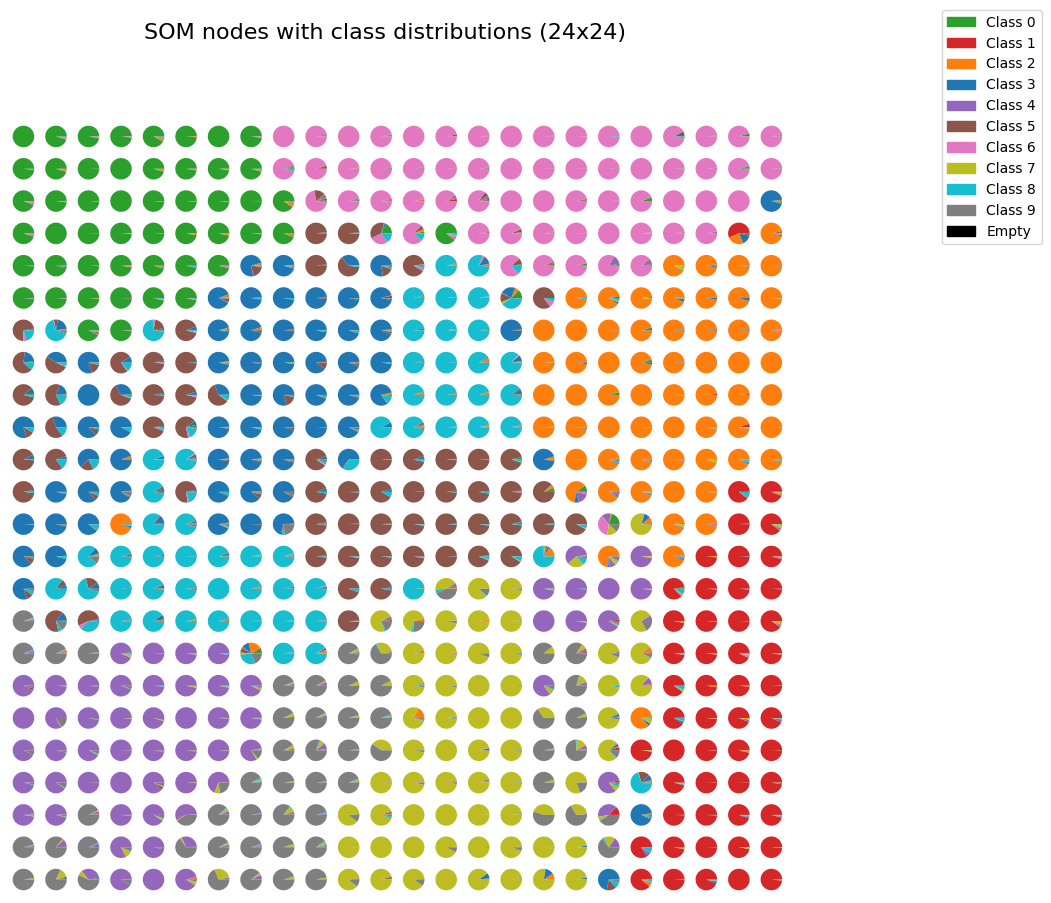

In [27]:
plot_som_pie_grid(snapshot_som_weights, config_paper['som_rows'], config_paper['som_cols'], unique_labels)

## ViT-SOM with 40x40 grid

In [16]:
config_paper_big = {
    'img_size': 28,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'som_rows': 40,
    'som_cols': 40,
    'epochs': 100,
    'lr': 0.0005,
}

Initialize the ViT-SOM

Details:
- Image size of 28
- Pixel size of 4
- 1 image channel
- Embedding dimension of 16
- Encoder depth of 4
- Decoder depth of 2
- 2 self-attention head
- MLP hidden dimension of size 64
- 40 SOM rows
- 40 SOM columns
- 100 training epochs


In [17]:
autoencoder_big = AutoEncoder(img_size=config_paper_big['img_size'], 
                          patch_size=config_paper_big['patch_size'], 
                          num_of_channels=config_paper_big['num_of_channels'], 
                          embed_dim=config_paper_big['embed_dim'], 
                          enc_depth=config_paper_big['enc_depth'],                                      
                          dec_depth=config_paper_big['dec_depth'], 
                          num_heads=config_paper_big['num_heads'], 
                          mlp_dim=config_paper_big['mlp_dim'], 
                          som_rows=config_paper_big['som_rows'], 
                          som_cols=config_paper_big['som_cols'])    

In [18]:
# Initialize optimizer, dataloader, loss functions and scheduler
optimizer = optim.AdamW(autoencoder_big.parameters(), lr=config_paper_big['lr'])
loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
criterionViT = ViTLoss()
criterionSOM = SomLoss()
scheduler = CosineAnnealingLR(optimizer, T_max=config_paper_big['epochs'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder_big.to(device)
autoencoder_big.train()

# starting and ending value of sigma, beta is calculated to reach sigma_end at last epoch
sigma_start = config_paper_big['som_rows'] / 2.0
sigma_end = 0.001
beta = (sigma_end / sigma_start) ** (1 / config_paper_big['epochs'])

# get grid coordinates of each cell on the SOM grid
grid_coords = get_grid_coords(config_paper_big['som_rows'], config_paper_big['som_cols'], device)
current_sigma = sigma_start

history = {'total': [], 'mse': [], 'som': [], 'purity': [], 'QE': [], 'TE': []}

# checkpoints and snapshots for visualizations
checkpoints = [0,10,20,30,40,50,60,70,80,90,100]
snapshot_som_weights = {}

snapshot_som_weights[0] = (
    autoencoder_big.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder_big, loader, device)
)

# set to calculate unique labels
unique_labels = set()

warmup_epochs = 20
target_gamma = 0.01
print("Start training")
for epoch in range(config_paper_big['epochs']):
    running_loss = 0.0
    running_mse = 0.0
    running_som = 0.0

    # calculate current sigma value
    sigma_t = decay_exponential(sigma_start, beta, epoch)
    
    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent = autoencoder_big(images)
        som_weights = autoencoder_big.get_som_weights()
        
        # calculate the total loss using the linear warmup
        l_nn = criterionViT(images, reconstructed)
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        if epoch < warmup_epochs:
            gamma = target_gamma * (epoch / warmup_epochs)
        else:
            gamma = target_gamma
        total_loss = l_nn + gamma * l_som
        
        # update the weights of the network
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_mse += l_nn.item()
        running_som += l_som.item()
    
    if epoch+1 in checkpoints:      
        weights_np = autoencoder_big.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder_big, loader, device)
        snapshot_som_weights[epoch+1] = (weights_np, labels_np)
        
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()
    metrics = calculate_QE_TE_Purity(autoencoder_big, loader, device)
    
    avg_total = running_loss / len(loader)
    avg_mse = running_mse / len(loader)
    avg_som = running_som / len(loader)
    
    history['total'].append(avg_total)
    history['mse'].append(avg_mse)
    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config_paper_big['epochs']} | Sigma: {sigma_t:.2f} | Loss: {avg_total:.8f} (MSE: {avg_mse:.8f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")


Start training
Epoch 1/100 | Sigma: 20.00 | Loss: 0.01287975 (MSE: 0.01287975 | SOM: 907.68563249) | QE: 0.8833 | TE: 0.9913 | Purity: 0.24666
Epoch 2/100 | Sigma: 18.11 | Loss: 0.16472259 (MSE: 0.00170551 | SOM: 326.03413019) | QE: 0.0646 | TE: 1.0000 | Purity: 0.11253
Epoch 3/100 | Sigma: 16.41 | Loss: 0.02725709 (MSE: 0.00115802 | SOM: 26.09906947) | QE: 0.0010 | TE: 1.0000 | Purity: 0.11654
Epoch 4/100 | Sigma: 14.86 | Loss: 0.00284713 (MSE: 0.00097512 | SOM: 1.24800522) | QE: 0.0002 | TE: 0.8655 | Purity: 0.50853
Epoch 5/100 | Sigma: 13.46 | Loss: 0.00109108 (MSE: 0.00081403 | SOM: 0.13852491) | QE: 0.0002 | TE: 0.5353 | Purity: 0.63093
Epoch 6/100 | Sigma: 12.19 | Loss: 0.00087239 (MSE: 0.00068938 | SOM: 0.07320640) | QE: 0.0002 | TE: 0.2131 | Purity: 0.60883
Epoch 7/100 | Sigma: 11.04 | Loss: 0.00080896 (MSE: 0.00063888 | SOM: 0.05669252) | QE: 0.0001 | TE: 0.1348 | Purity: 0.61710
Epoch 8/100 | Sigma: 10.00 | Loss: 0.00076186 (MSE: 0.00060465 | SOM: 0.04491791) | QE: 0.0001 | T

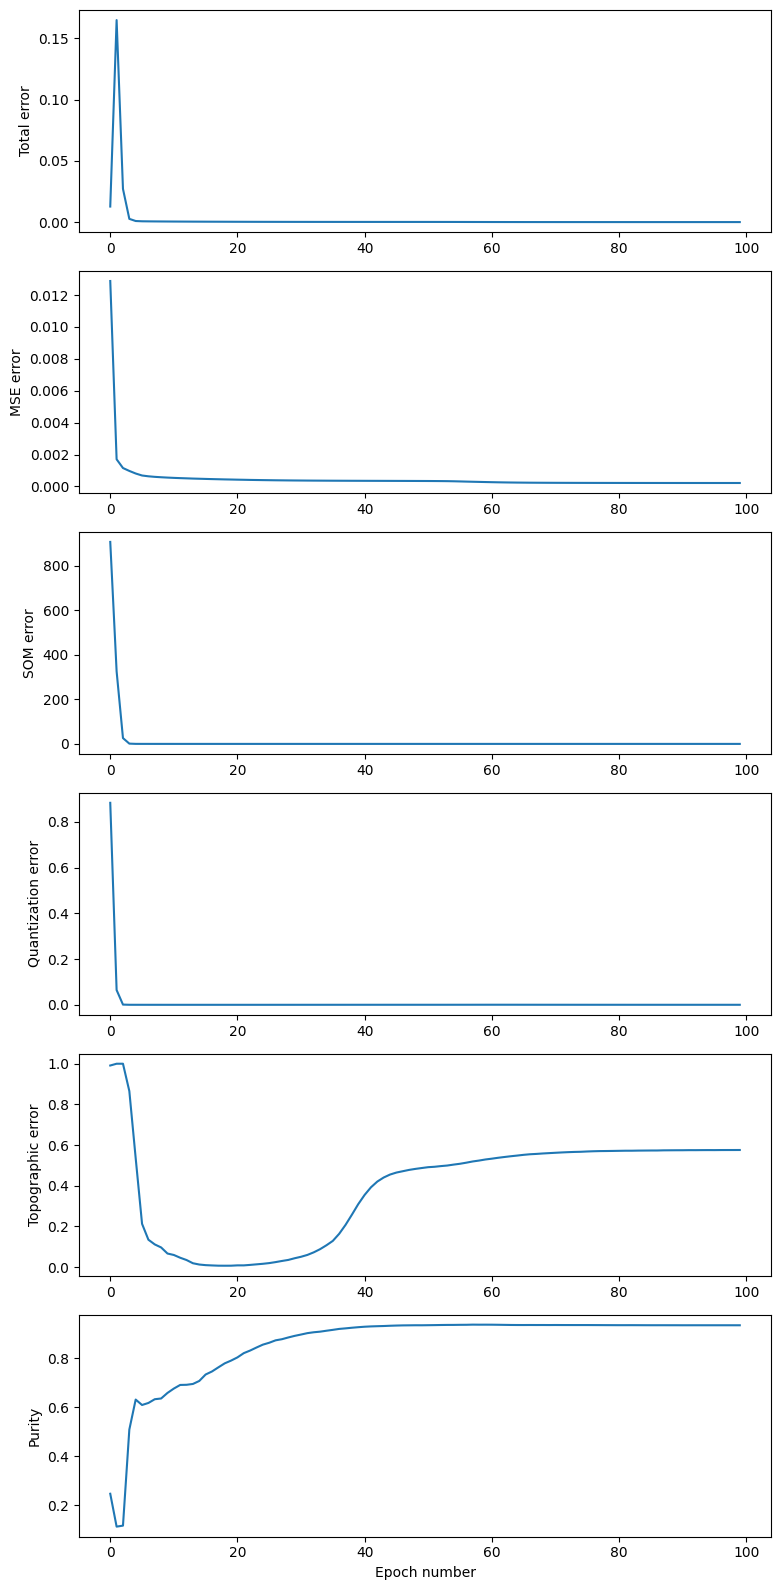

In [19]:
plt.figure(figsize=(8, 16))
plt.subplot(6,1,1)
plt.plot(np.arange(config_paper_big['epochs']), history['total'])
plt.ylabel('Total error')
plt.subplot(6,1,2)
plt.plot(np.arange(config_paper_big['epochs']), history['mse'])
plt.ylabel('MSE error')
plt.subplot(6,1,3)
plt.plot(np.arange(config_paper_big['epochs']), history['som'])
plt.ylabel('SOM error')
plt.subplot(6,1,4)
plt.plot(np.arange(config_paper_big['epochs']), history['QE'])
plt.ylabel('Quantization error')
plt.subplot(6,1,5)
plt.plot(np.arange(config_paper_big['epochs']), history['TE'])
plt.ylabel('Topographic error')
plt.subplot(6,1,6)
plt.plot(np.arange(config_paper_big['epochs']), history['purity'])
plt.ylabel('Purity')
plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

Plot the change of the label matrix throughout the training process

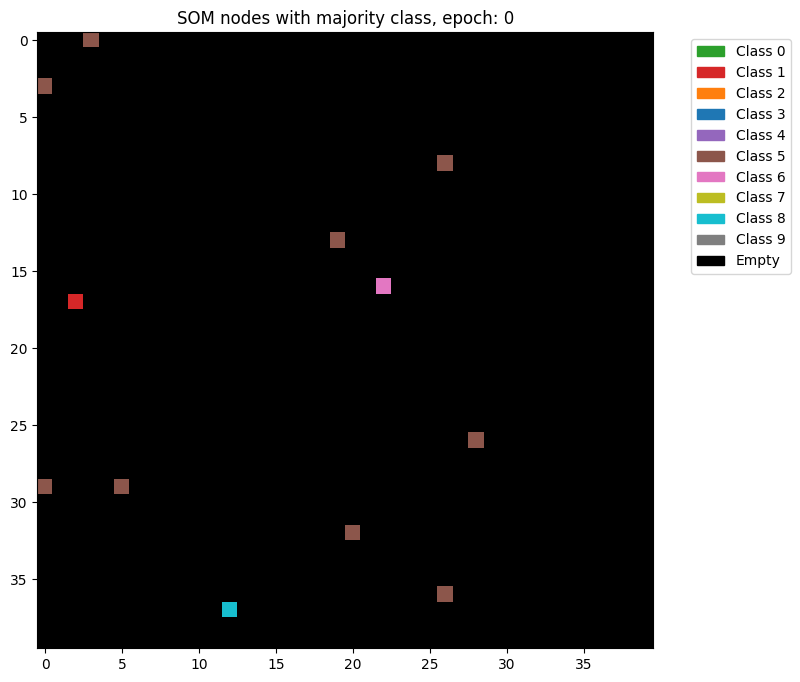

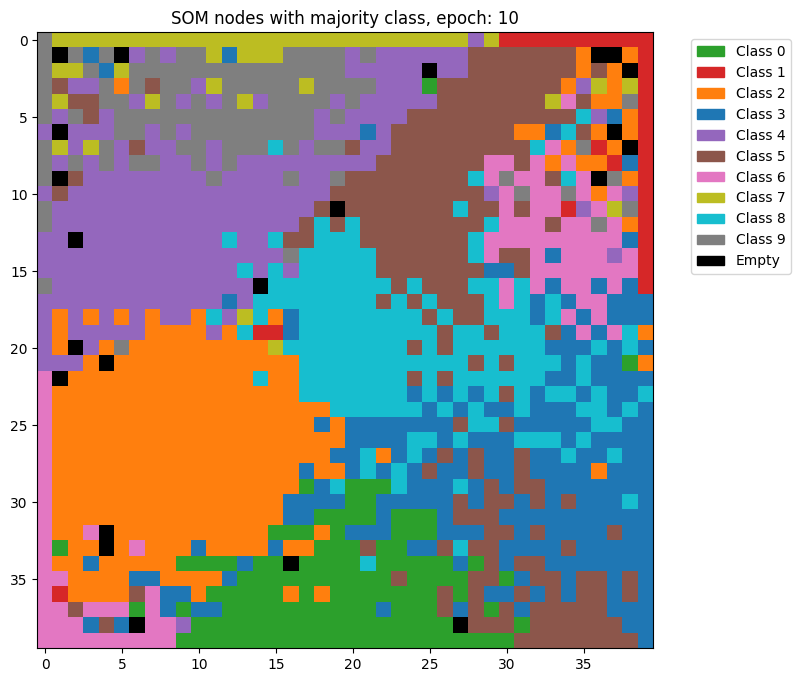

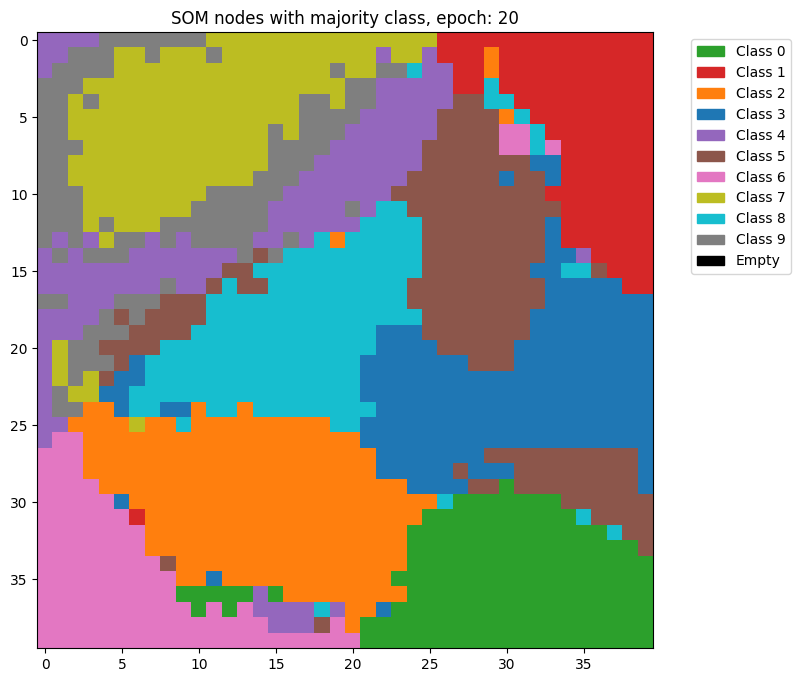

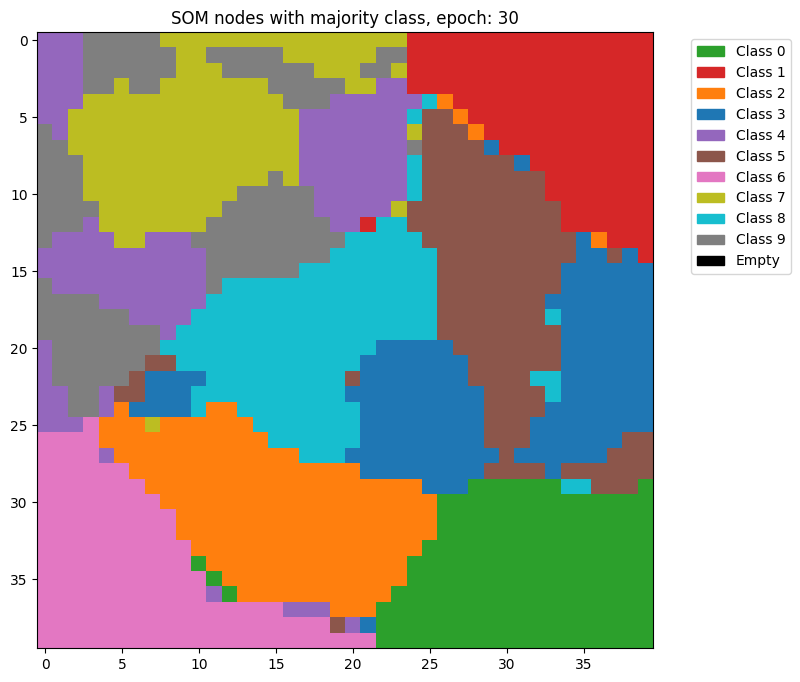

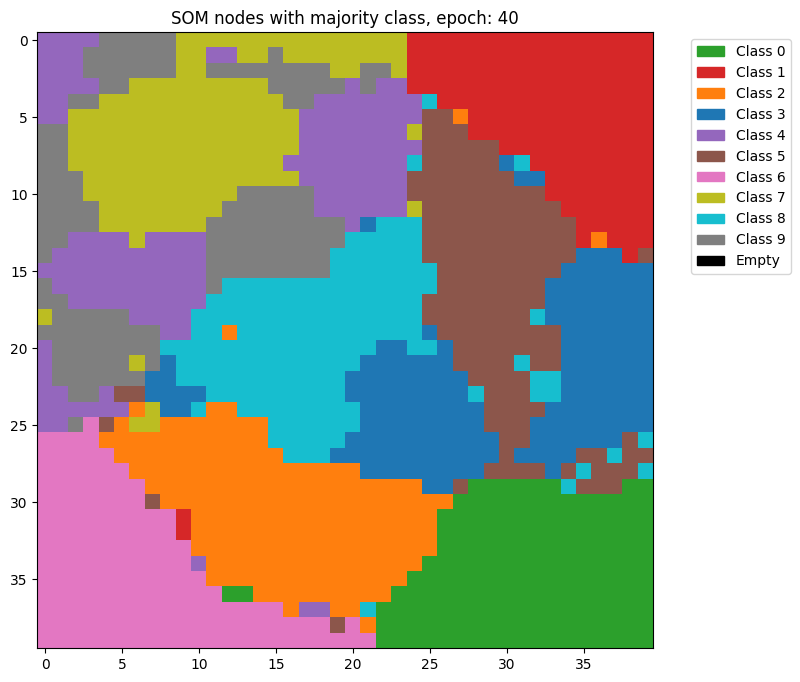

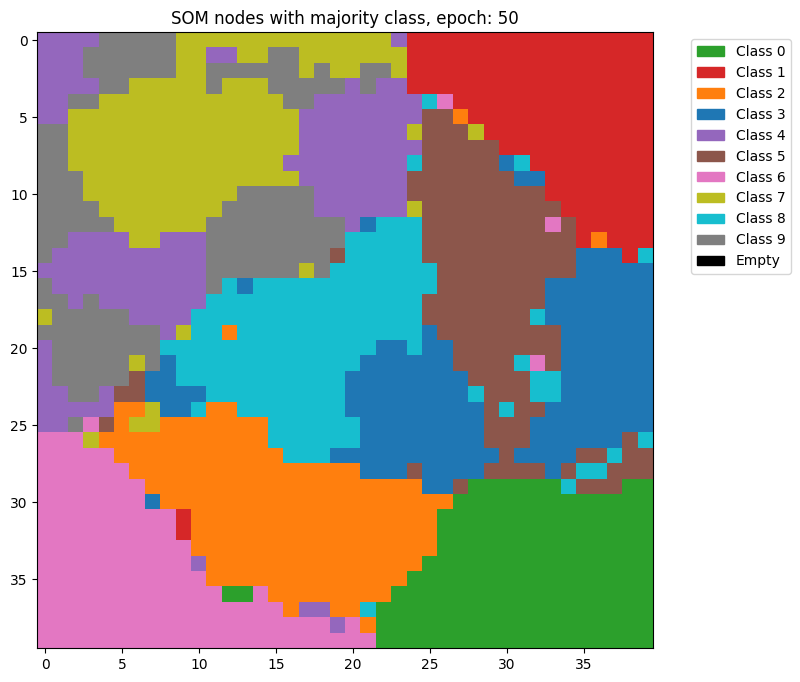

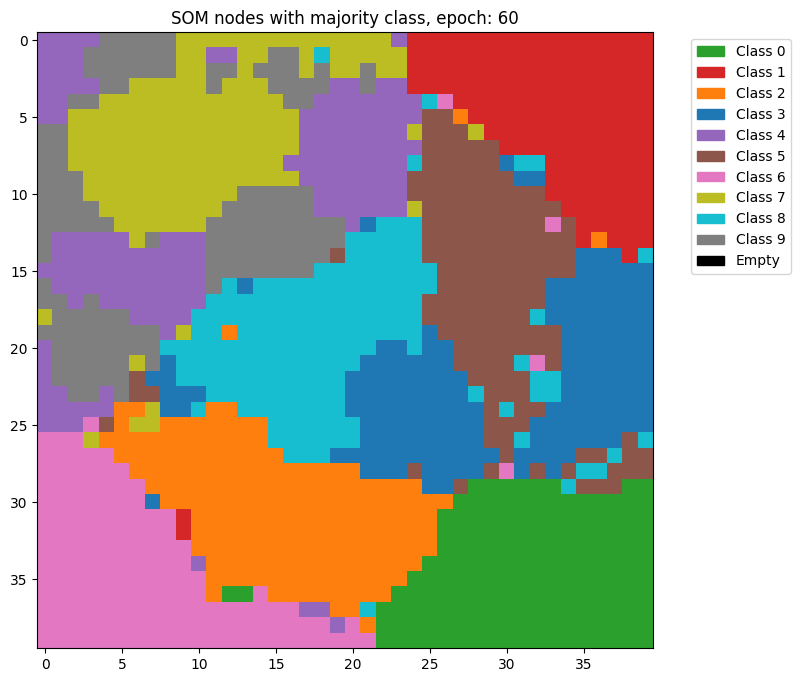

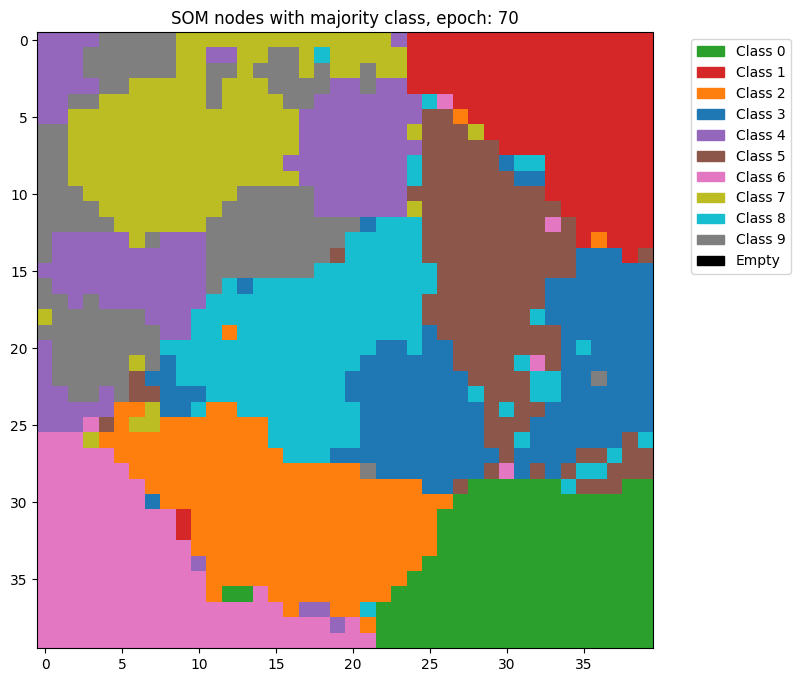

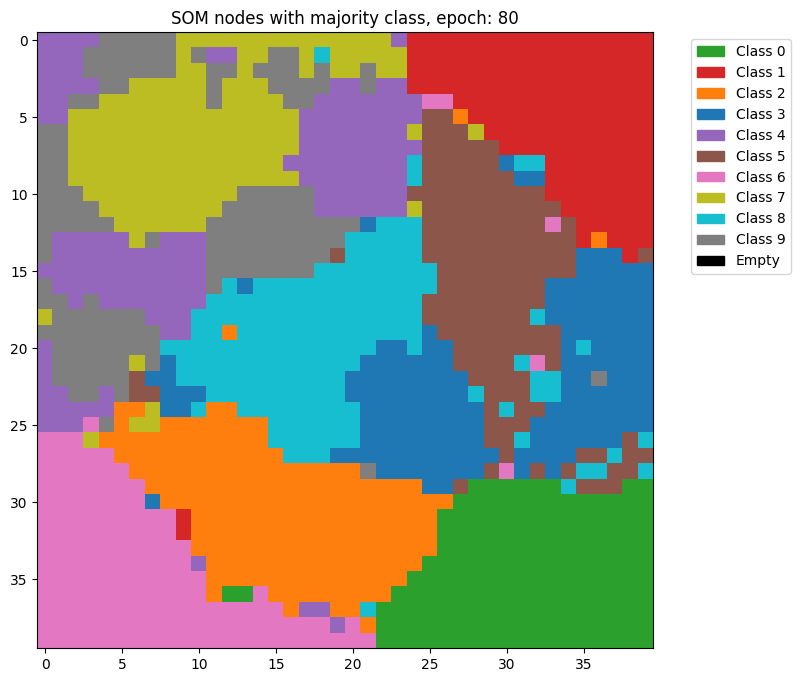

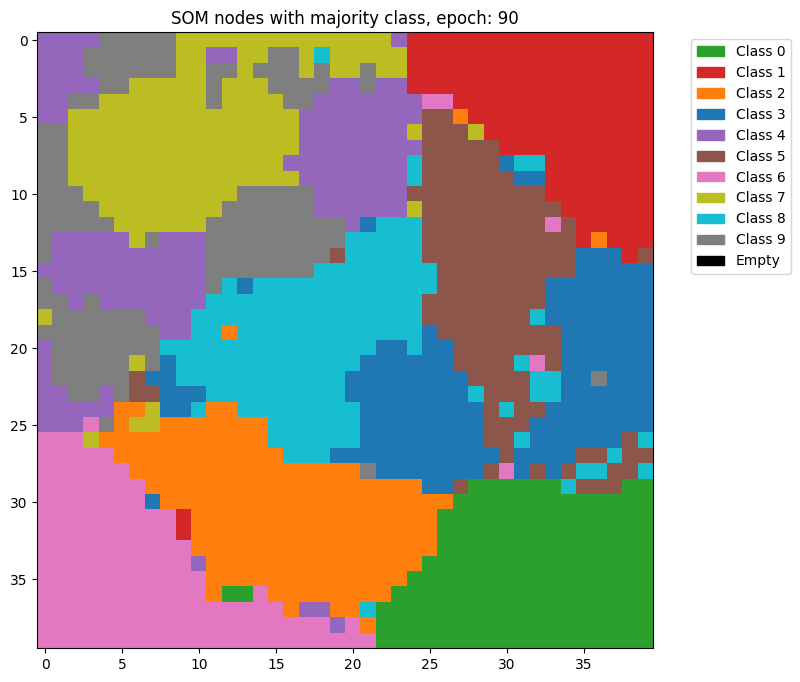

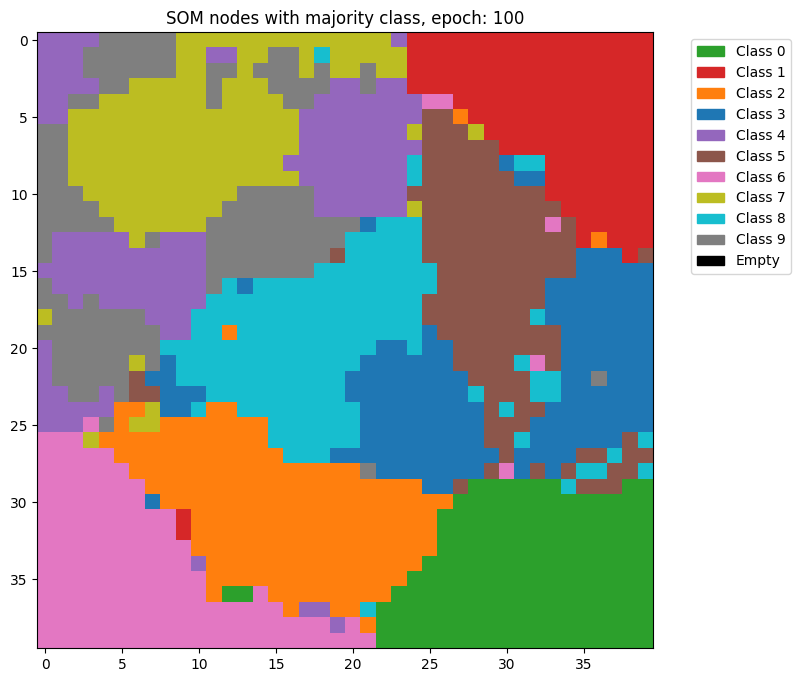

In [20]:
plot_som_weights(snapshot_som_weights, config_paper_big['som_rows'], config_paper_big['som_cols'], unique_labels)

Plot the change of the UMAP throughout the training process

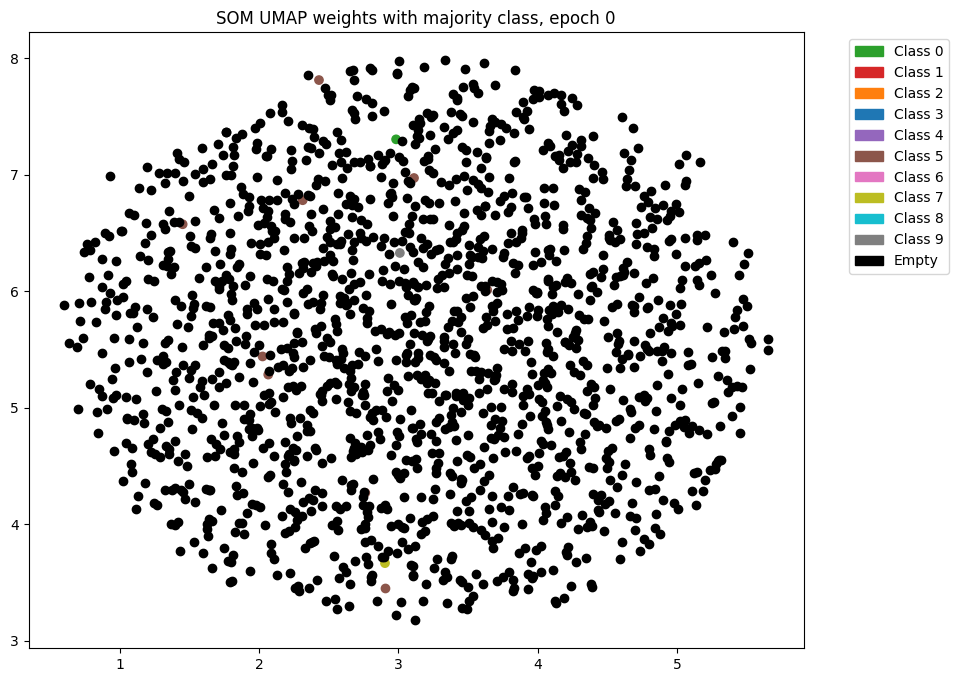

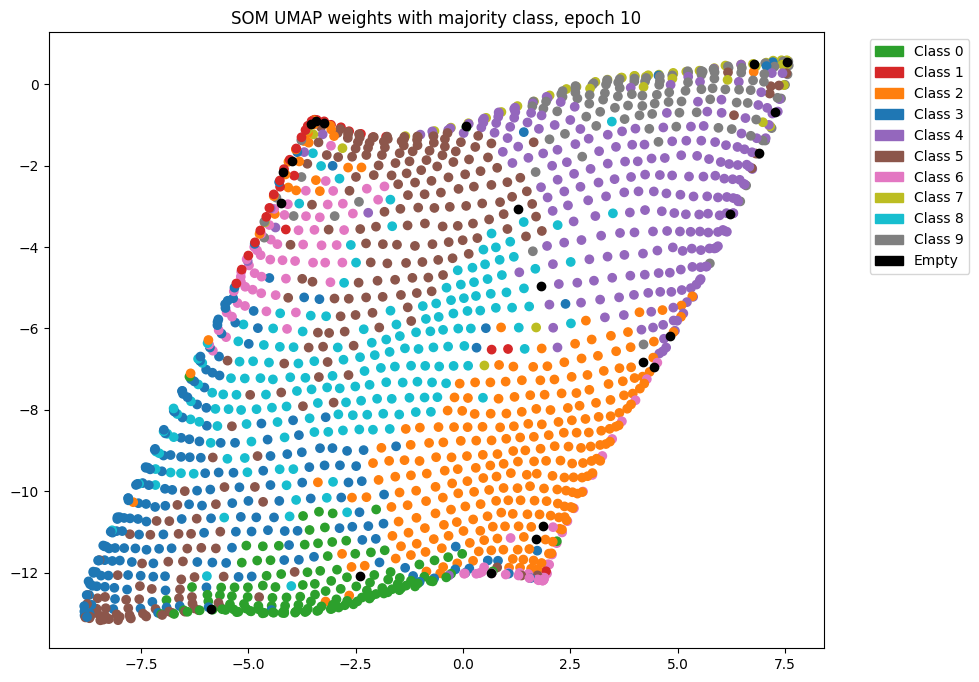

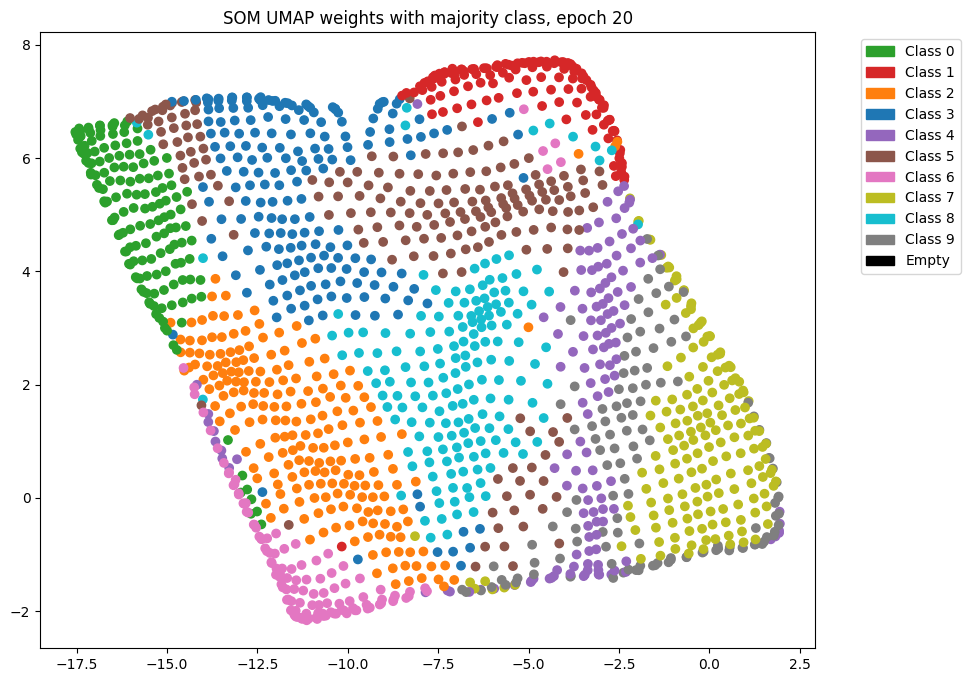

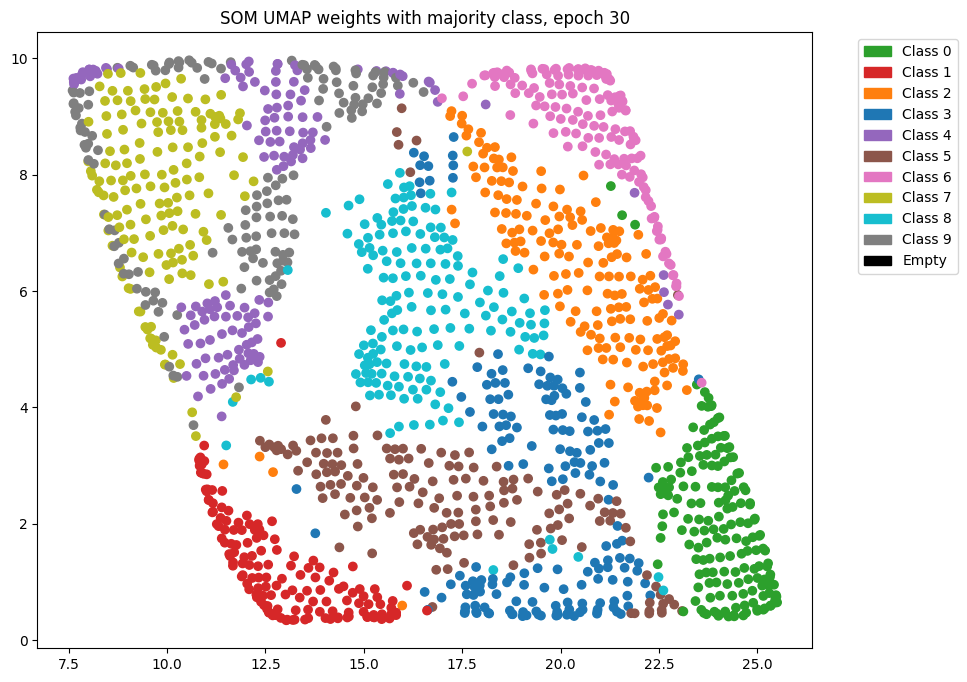

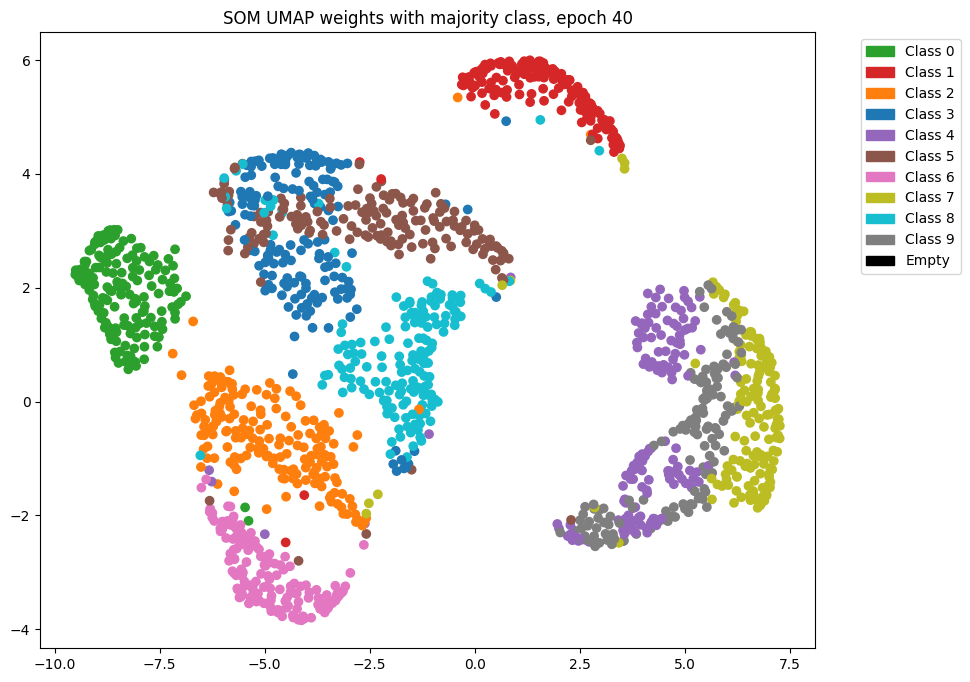

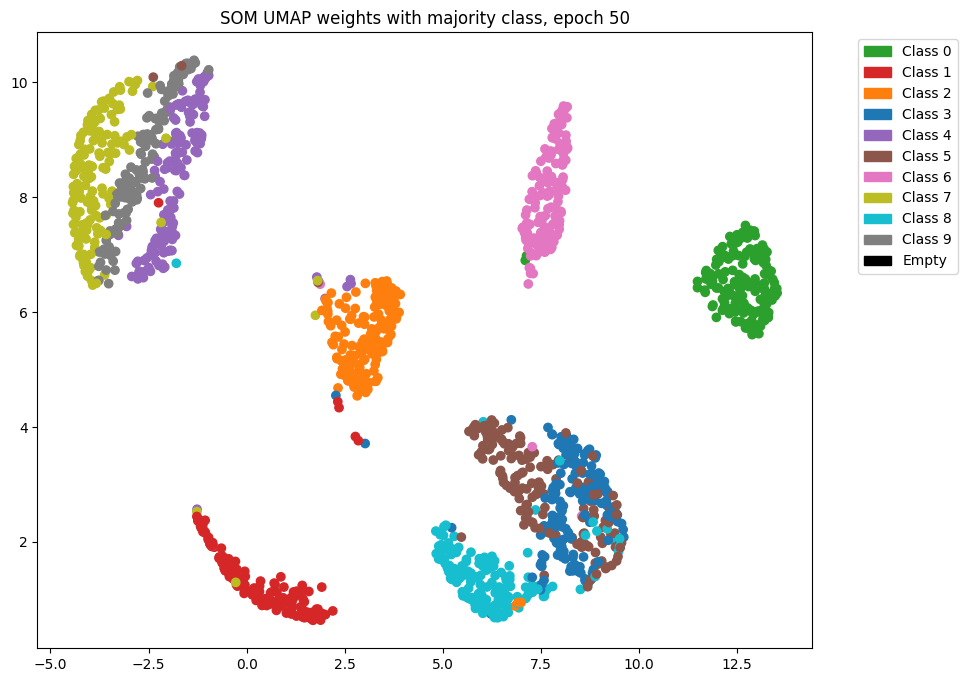

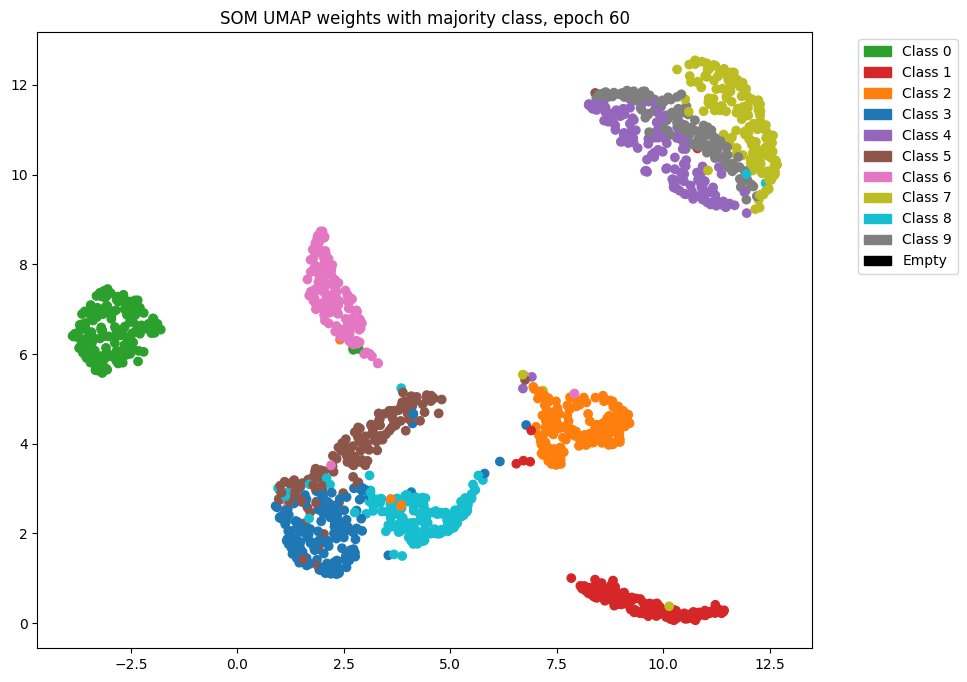

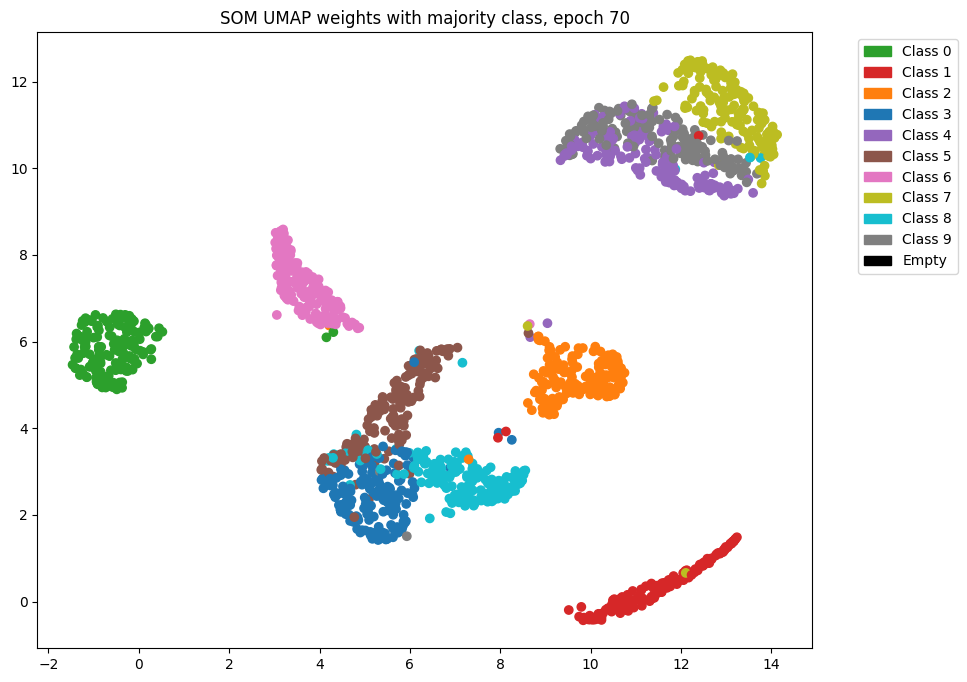

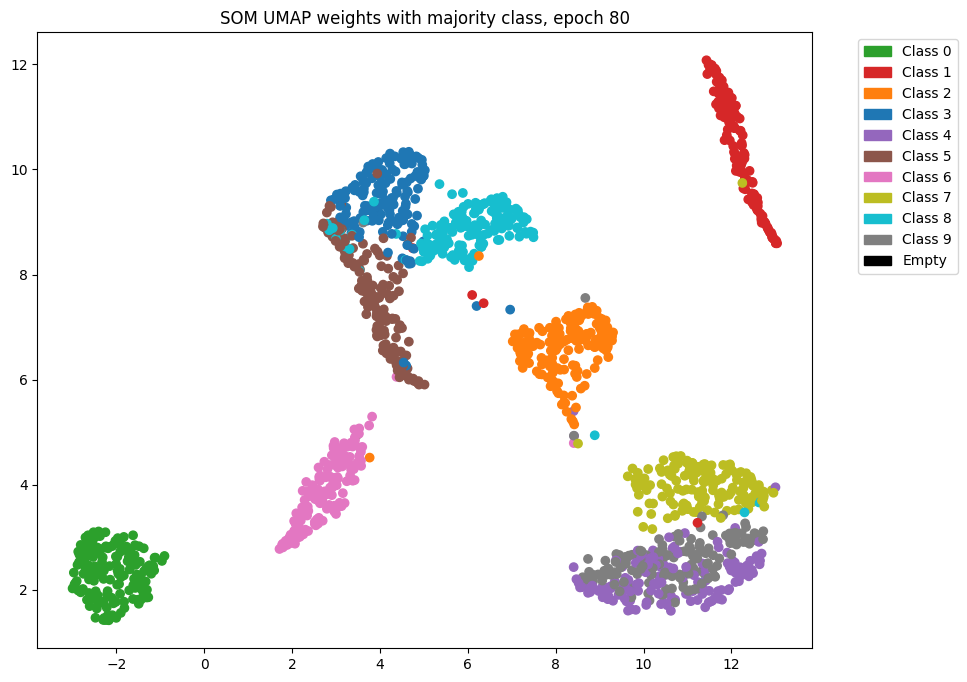

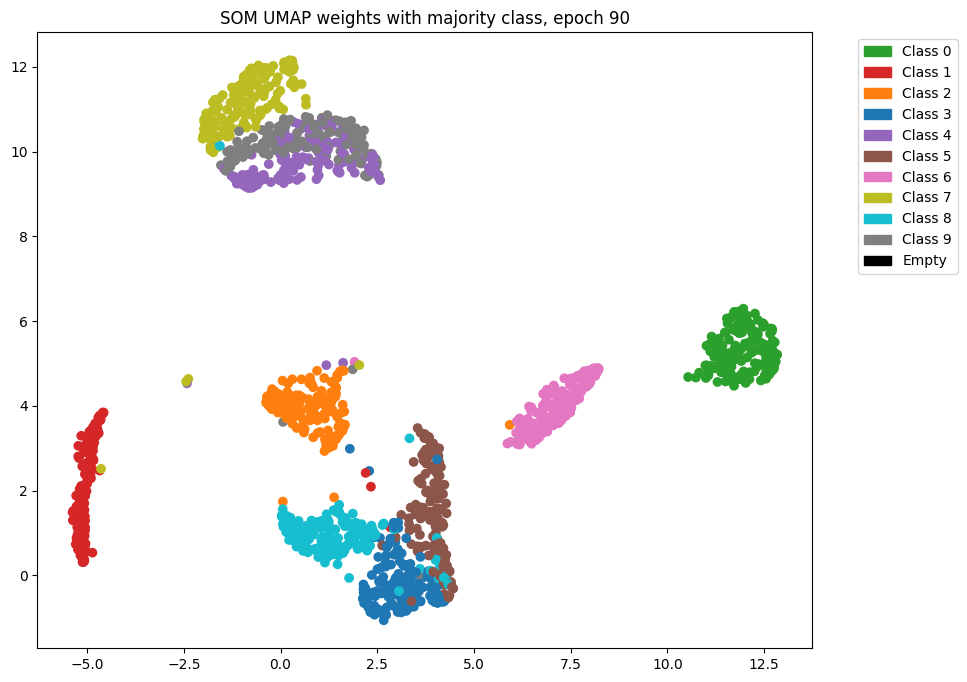

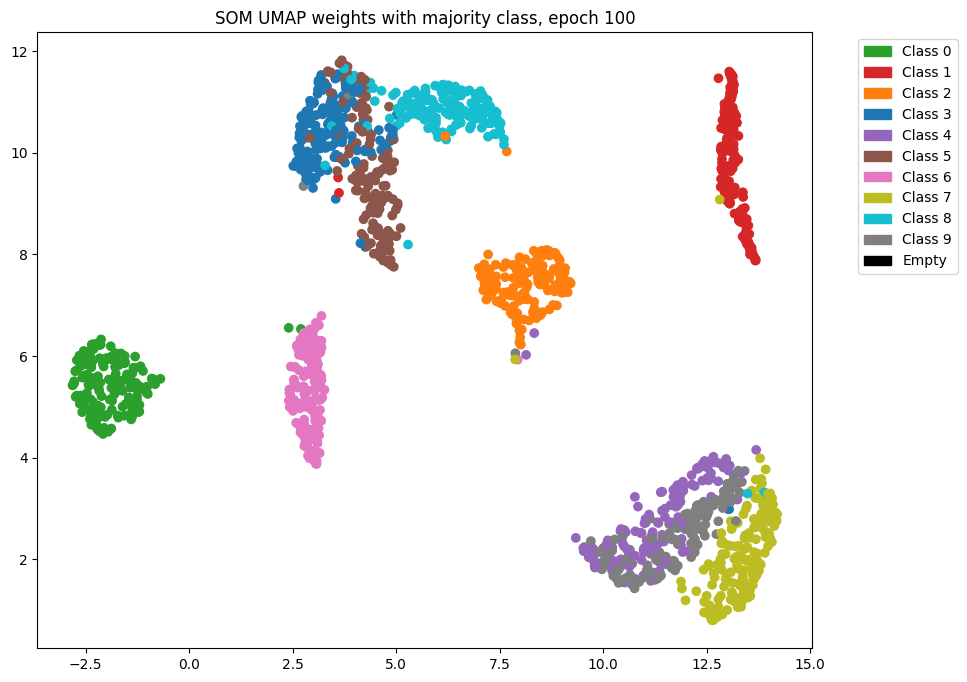

In [21]:
plot_umap_som_weights(snapshot_som_weights, unique_labels)

Plot the majority class with the numbers representing the class

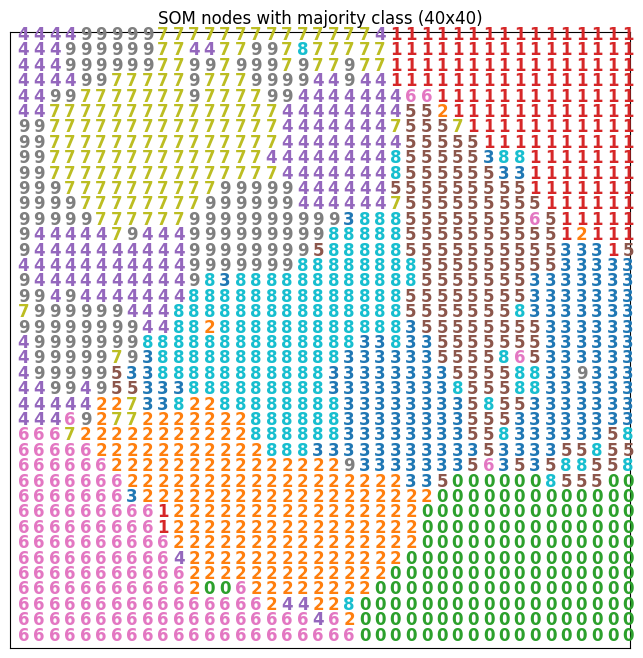

In [22]:
plot_som_mnist(snapshot_som_weights, config_paper_big['som_rows'], config_paper_big['som_cols'])

Plot the pie charts with internal class distributions

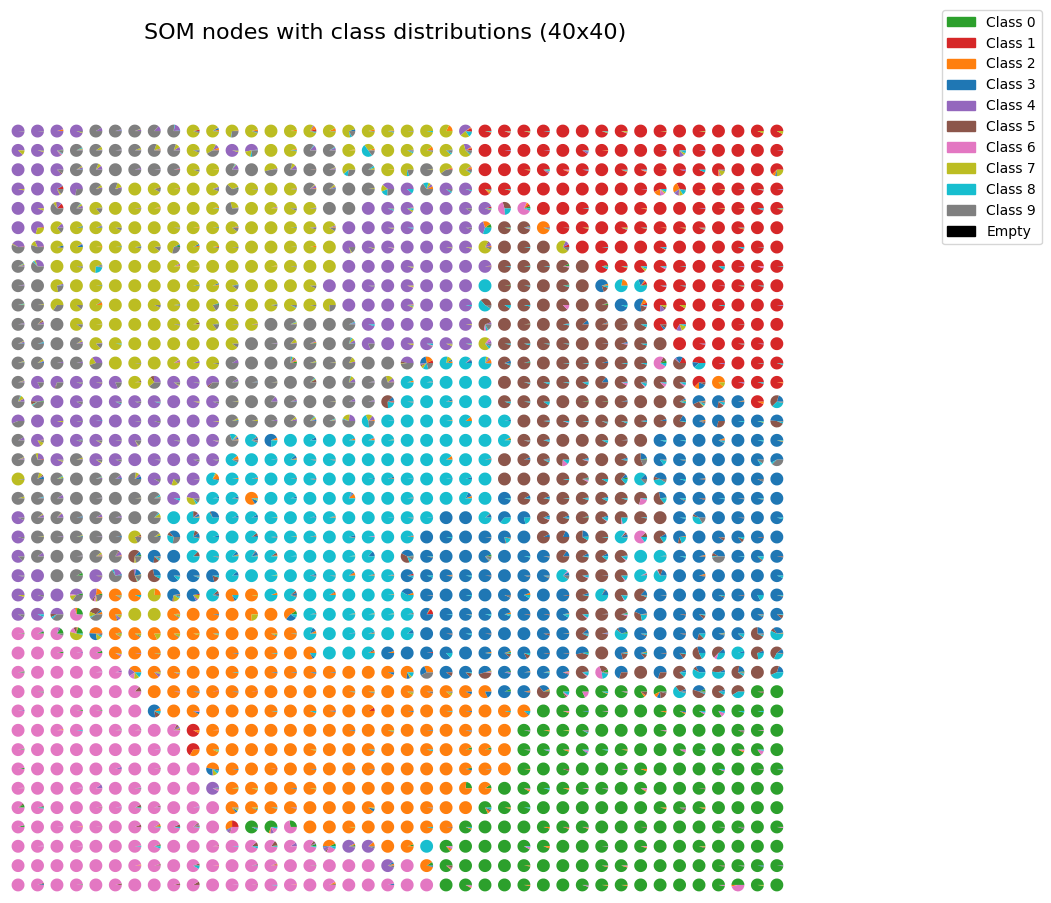

In [23]:
plot_som_pie_grid(snapshot_som_weights, config_paper_big['som_rows'], config_paper_big['som_cols'], unique_labels)